In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, re, math, pickle, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

from specparam import Bands
from spk_feat_cluster_analysis import *
from spe1_plotting import *
from config import (NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED,
                    DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT,
                    SPE1_PICKLE_ROOT, LFP_FS)

warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated",
                        category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", message=r"invalid value encountered in log10",
                        category=RuntimeWarning, module=r".*specparam.*")

In [2]:
# ── Cell configuration ────────────────────────────────────────────────────────
cell_num = 26

lfp_fs   = LFP_FS
patch_fs = DICT_PATCH_FS[cell_num]

# Force-recompute flags — all True on first run, set False to load from cache
FORCE_LFP     = False   # LFP window extraction + specparam computation
FORCE_SIMPLE  = False   # Simple LFP features (mean, std, spectral exponent)
FORCE_STATS   = True   # Sliding-window statistical analysis
FORCE_PREPOST = False   # Pre/post spike specparam comparison

## 1. Load Data

In [3]:
# Load recordings and cluster DataFrame
lfp_dir   = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings',  f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')

lfp_filt   = np.load(lfp_dir)
patch_filt = np.load(patch_dir)
lfp_times  = np.arange(len(lfp_filt)) / (lfp_fs  / 1000.0)  # ms

cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')
with open(cluster_pickle, 'rb') as f:
    df_features_clust = pickle.load(f)
print(f"Loaded {len(df_features_clust)} spikes | cluster cols: {[c for c in df_features_clust.columns if '_cluster' in c]}")

Loaded 5824 spikes | cluster cols: ['log_isi_cluster']


## 2. LFP Windows & Specparam

In [4]:
# Extract or load LFP windows around each spike
lfp_win_pickle = os.path.join(SPE1_PICKLE_ROOT, 'lfp_window_pickles', f'c{cell_num}_lfp_windows.pkl')

if FORCE_LFP or not os.path.exists(lfp_win_pickle):
    all_spike_extractor = extract_lfp_windows(
        spk_df=df_features_clust,
        lfp_times_ms=lfp_times,
        lfp_signal=lfp_filt,
        pre_s=1.0, post_s=1.5,
        condition=None,
    )
    with open(lfp_win_pickle, 'wb') as f:
        pickle.dump(all_spike_extractor, f)
    print(f"  Saved: {os.path.basename(lfp_win_pickle)}")
else:
    print(f"  [cache] {os.path.basename(lfp_win_pickle)}")
    with open(lfp_win_pickle, 'rb') as f:
        all_spike_extractor = pickle.load(f)

windows_all  = all_spike_extractor["windows"]
t_rel_all    = all_spike_extractor["times_rel_ms"]
next_spk_all = all_spike_extractor["next_spike_times_ms"]

  Saved: c26_lfp_windows.pkl


In [5]:
# Compute or load per-spike time-resolved specparam
chunk_dir    = os.path.join(SPE1_PICKLE_ROOT, "multitaper_pickles", f"c{cell_num}")
chunk_prefix = f"c{cell_num}_specparam"
os.makedirs(chunk_dir, exist_ok=True)
existing_chunks = sorted(
    [f for f in os.listdir(chunk_dir) if f.startswith(chunk_prefix) and f.endswith(".pkl")],
    key=lambda f: int(re.search(r'_(\d+)\.pkl$', f).group(1))
)
n_total_chunks = math.ceil(len(windows_all) / 200)

if FORCE_LFP or len(existing_chunks) == 0:
    resume = 0
elif len(existing_chunks) < n_total_chunks:
    saved_idxs = [int(re.search(r'_(\d+)\.pkl$', f).group(1)) for f in existing_chunks]
    resume = max(saved_idxs) + 1
    print(f"  Resuming from chunk {resume}/{n_total_chunks - 1} ({len(existing_chunks)} already done)")
else:
    resume = None

if resume is not None:
    print(f"  Computing specparam for {len(windows_all)} spikes (chunked)...")
    specparam_by_spike = run_time_resolved_specparam_per_spike(
        lfp_windows        = windows_all,
        times_rel_list     = t_rel_all,
        next_rel_list      = next_spk_all,
        fs                 = lfp_fs,
        chunk_size         = 200,
        save_dir           = chunk_dir,
        save_prefix        = chunk_prefix,
        resume_start_chunk = resume,
        decim_factor       = 100,
        n_freqs            = 50,
    )
else:
    print(f"  [cache] {len(existing_chunks)}/{n_total_chunks} chunks — loading...")
    specparam_by_spike = load_chunked_specparam_results(save_dir=chunk_dir, prefix=chunk_prefix)

specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)
print(f"Specparam ready for {len(specparam_by_spike)} spikes")

  Computing specparam for 5818 spikes (chunked)...

Processing Chunk 0 (Spikes 0 to 199)...
Chunk 0/29: 100%|██████████| 200/200 [01:19<00:00,  2.51it/s]

Processing Chunk 1 (Spikes 200 to 399)...
Chunk 1/29: 100%|██████████| 200/200 [01:17<00:00,  2.60it/s]

Processing Chunk 2 (Spikes 400 to 599)...
Chunk 2/29: 100%|██████████| 200/200 [01:15<00:00,  2.65it/s]

Processing Chunk 3 (Spikes 600 to 799)...
Chunk 3/29: 100%|██████████| 200/200 [01:15<00:00,  2.63it/s]

Processing Chunk 4 (Spikes 800 to 999)...
Chunk 4/29: 100%|██████████| 200/200 [01:18<00:00,  2.56it/s]

Processing Chunk 5 (Spikes 1000 to 1199)...
Chunk 5/29: 100%|██████████| 200/200 [01:16<00:00,  2.60it/s]

Processing Chunk 6 (Spikes 1200 to 1399)...
Chunk 6/29: 100%|██████████| 200/200 [01:16<00:00,  2.60it/s]

Processing Chunk 7 (Spikes 1400 to 1599)...
Chunk 7/29: 100%|██████████| 200/200 [01:17<00:00,  2.58it/s]

Processing Chunk 8 (Spikes 1600 to 1799)...
Chunk 8/29: 100%|██████████| 200/200 [01:17<00:00,  2.59it/s

In [6]:
# Build spike groups and compute simple LFP features
groups = build_lfp_groups_from_clusters(df_features_clust, all_spike_extractor)
print(f"Groups: {list(groups.keys())}")

simple_pickle = os.path.join(SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl')
if FORCE_SIMPLE or not os.path.exists(simple_pickle):
    lfp_windows_by_spike = compute_simple_lfp_by_spike(
        windows_all=windows_all,
        times_rel_list=t_rel_all,
        fs=lfp_fs,
        inner_window_s=0.5,
        step_s=0.025,
        freq_range=(4, 90),
    )
    with open(simple_pickle, 'wb') as f:
        pickle.dump(lfp_windows_by_spike, f)
    print(f"  Saved: {os.path.basename(simple_pickle)}")
else:
    print(f"  [cache] {os.path.basename(simple_pickle)}")
    with open(simple_pickle, 'rb') as f:
        lfp_windows_by_spike = pickle.load(f)

Groups: ['log_isi_cluster: low', 'log_isi_cluster: high']
  Saved: c26_simple_lfp.pkl


## 3. Sliding-Window LFP Analysis

c26 features:   0%|          | 0/9 [00:00<?, ?feat/s]
  RUNNING PIPELINE FOR: APERIODIC EXPONENT



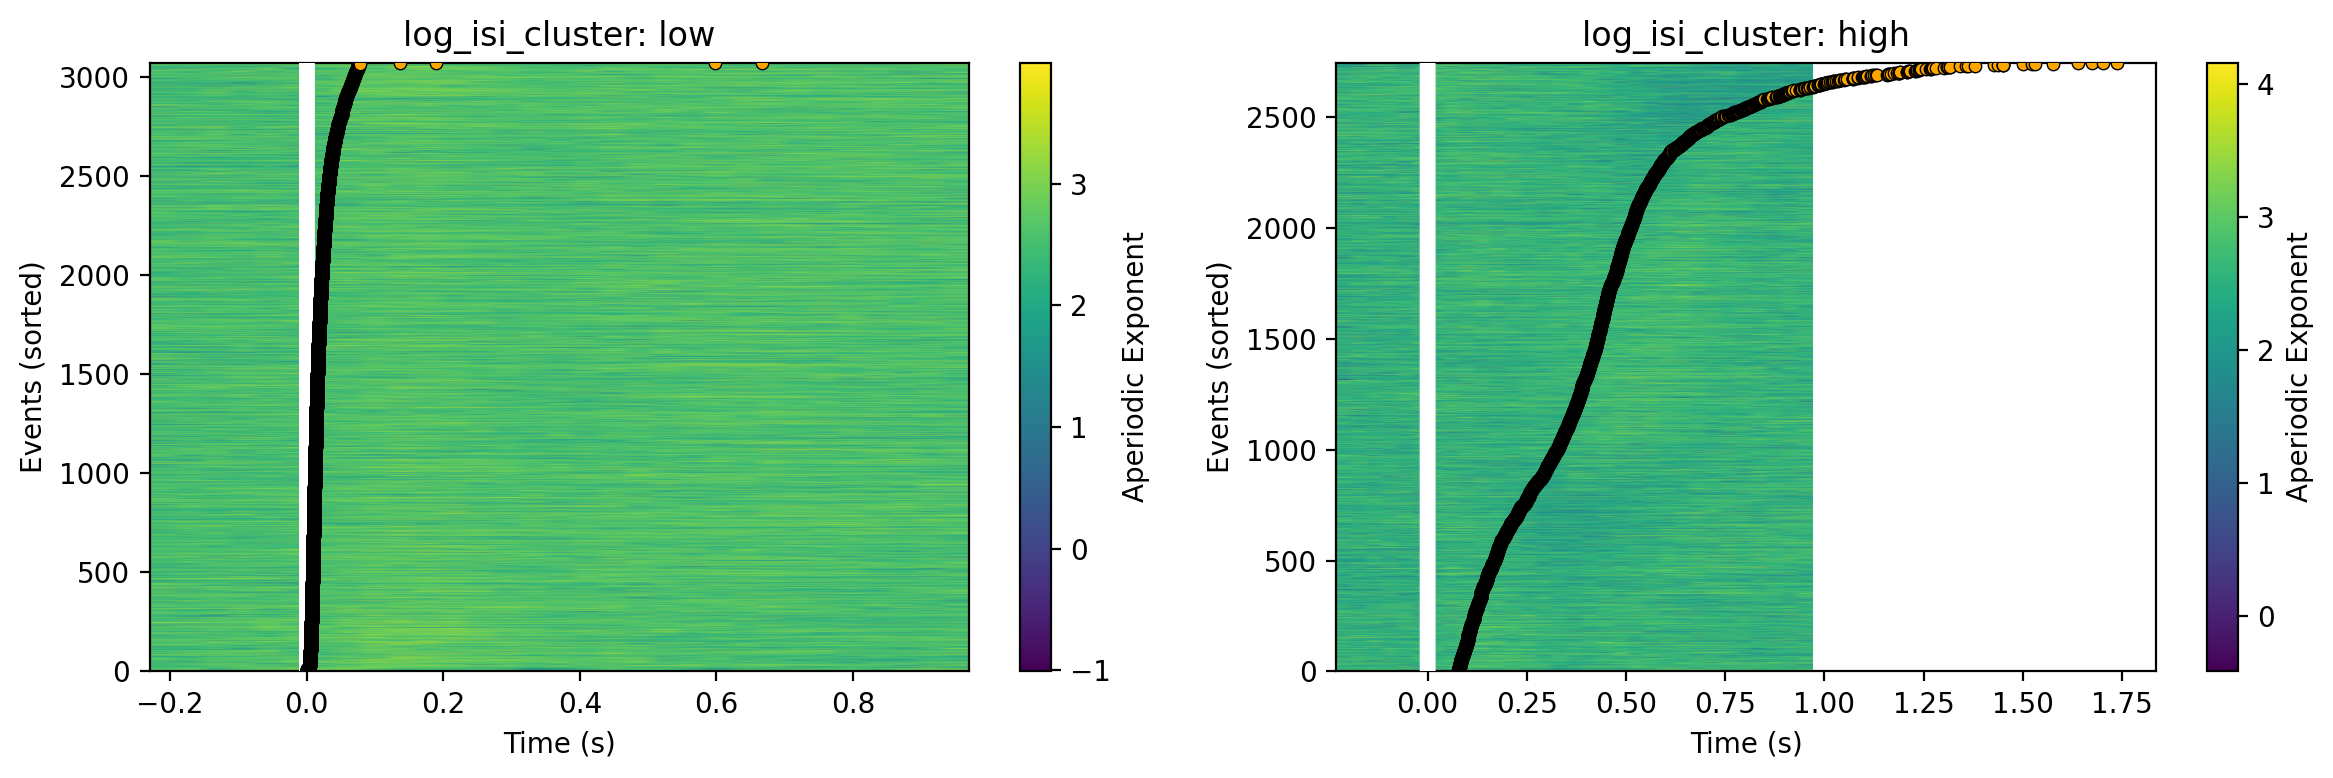

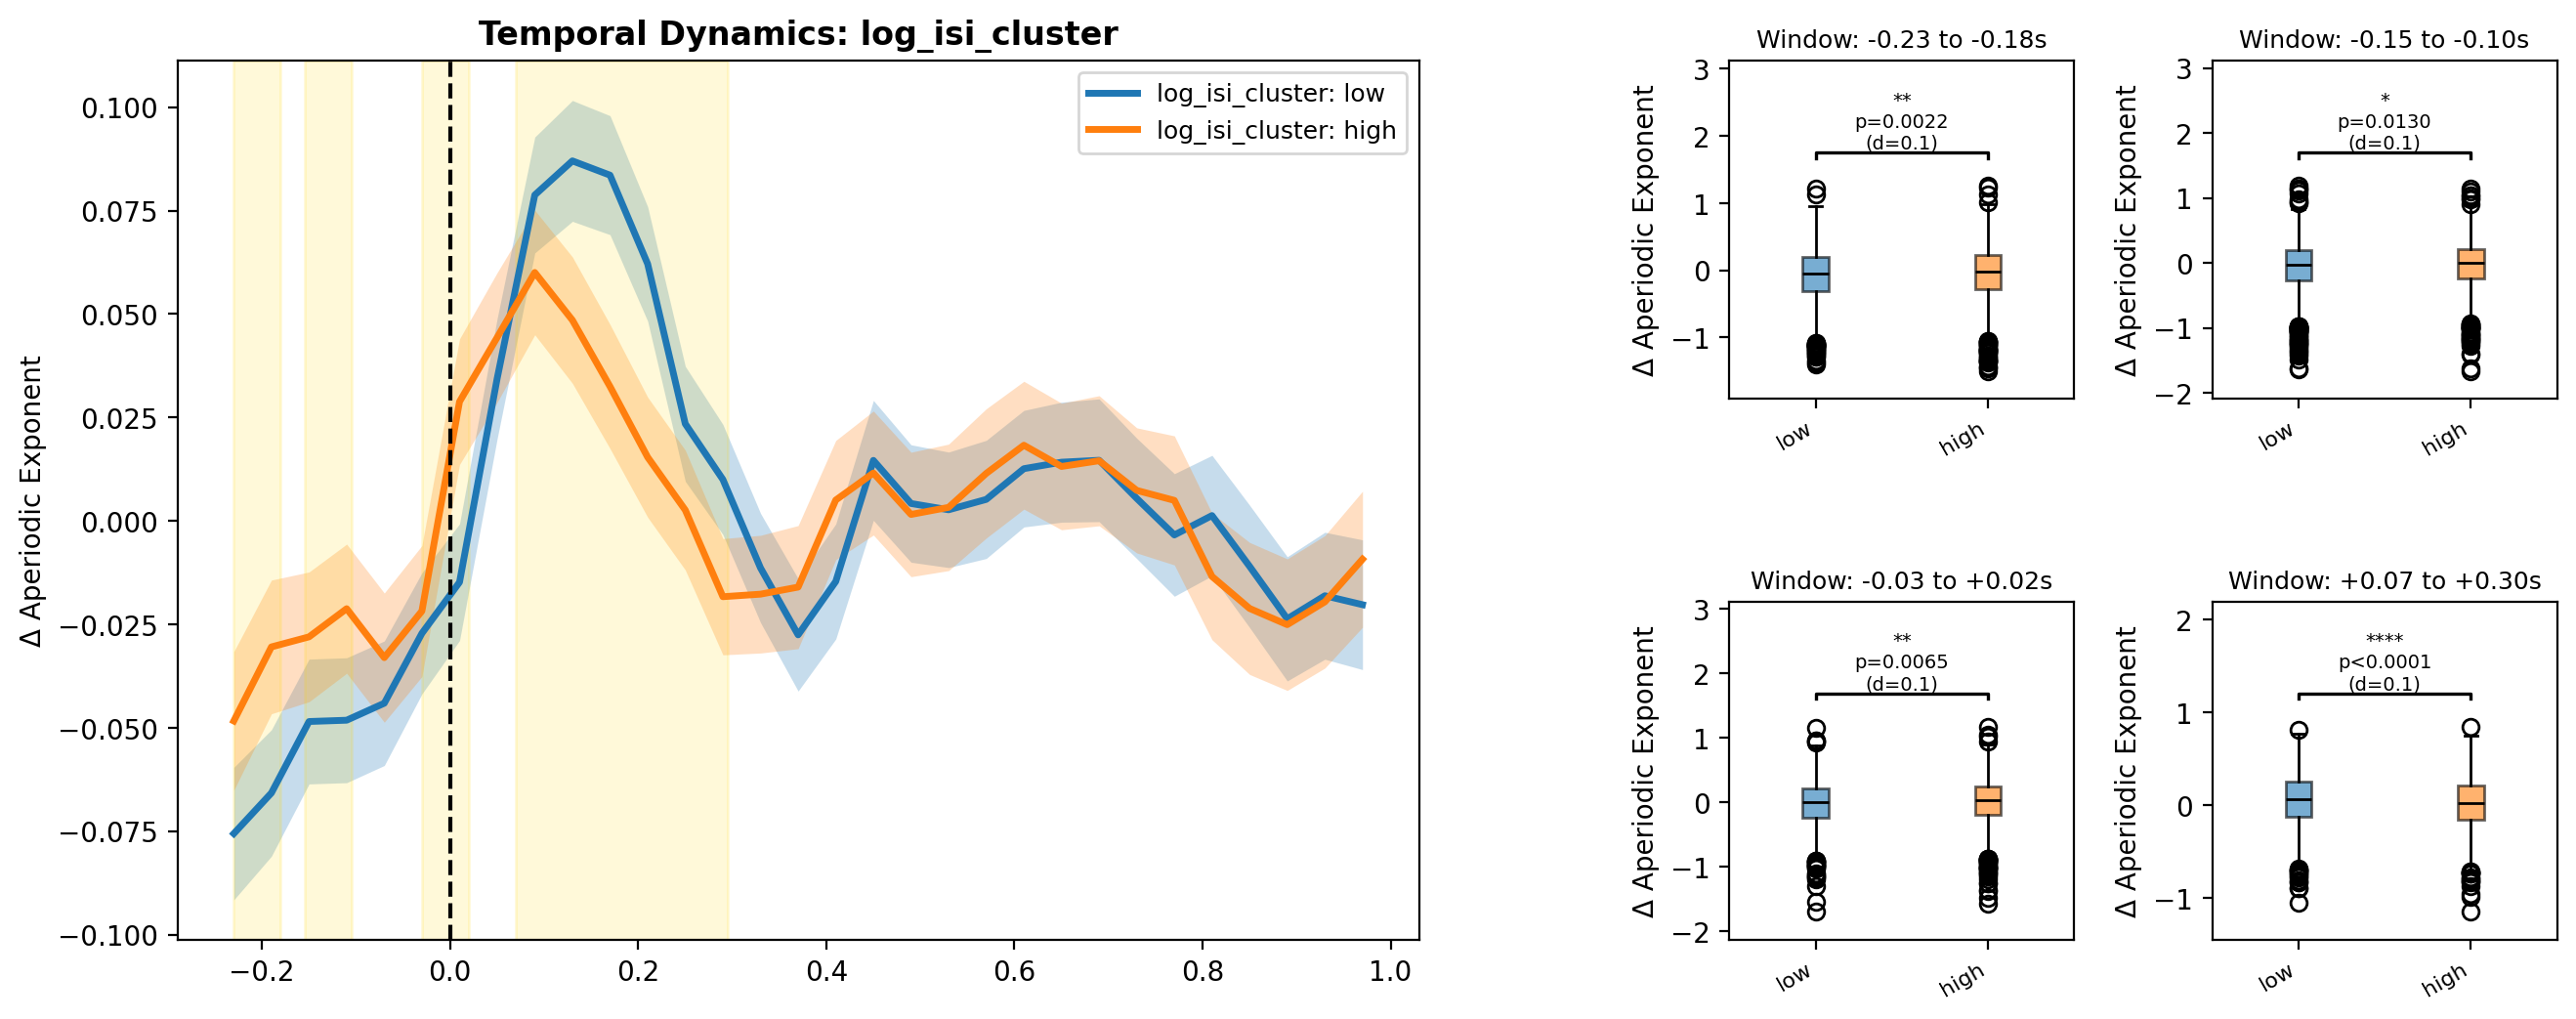

c26 features:  11%|█         | 1/9 [00:01<00:10,  1.36s/feat]
  RUNNING PIPELINE FOR: APERIODIC OFFSET



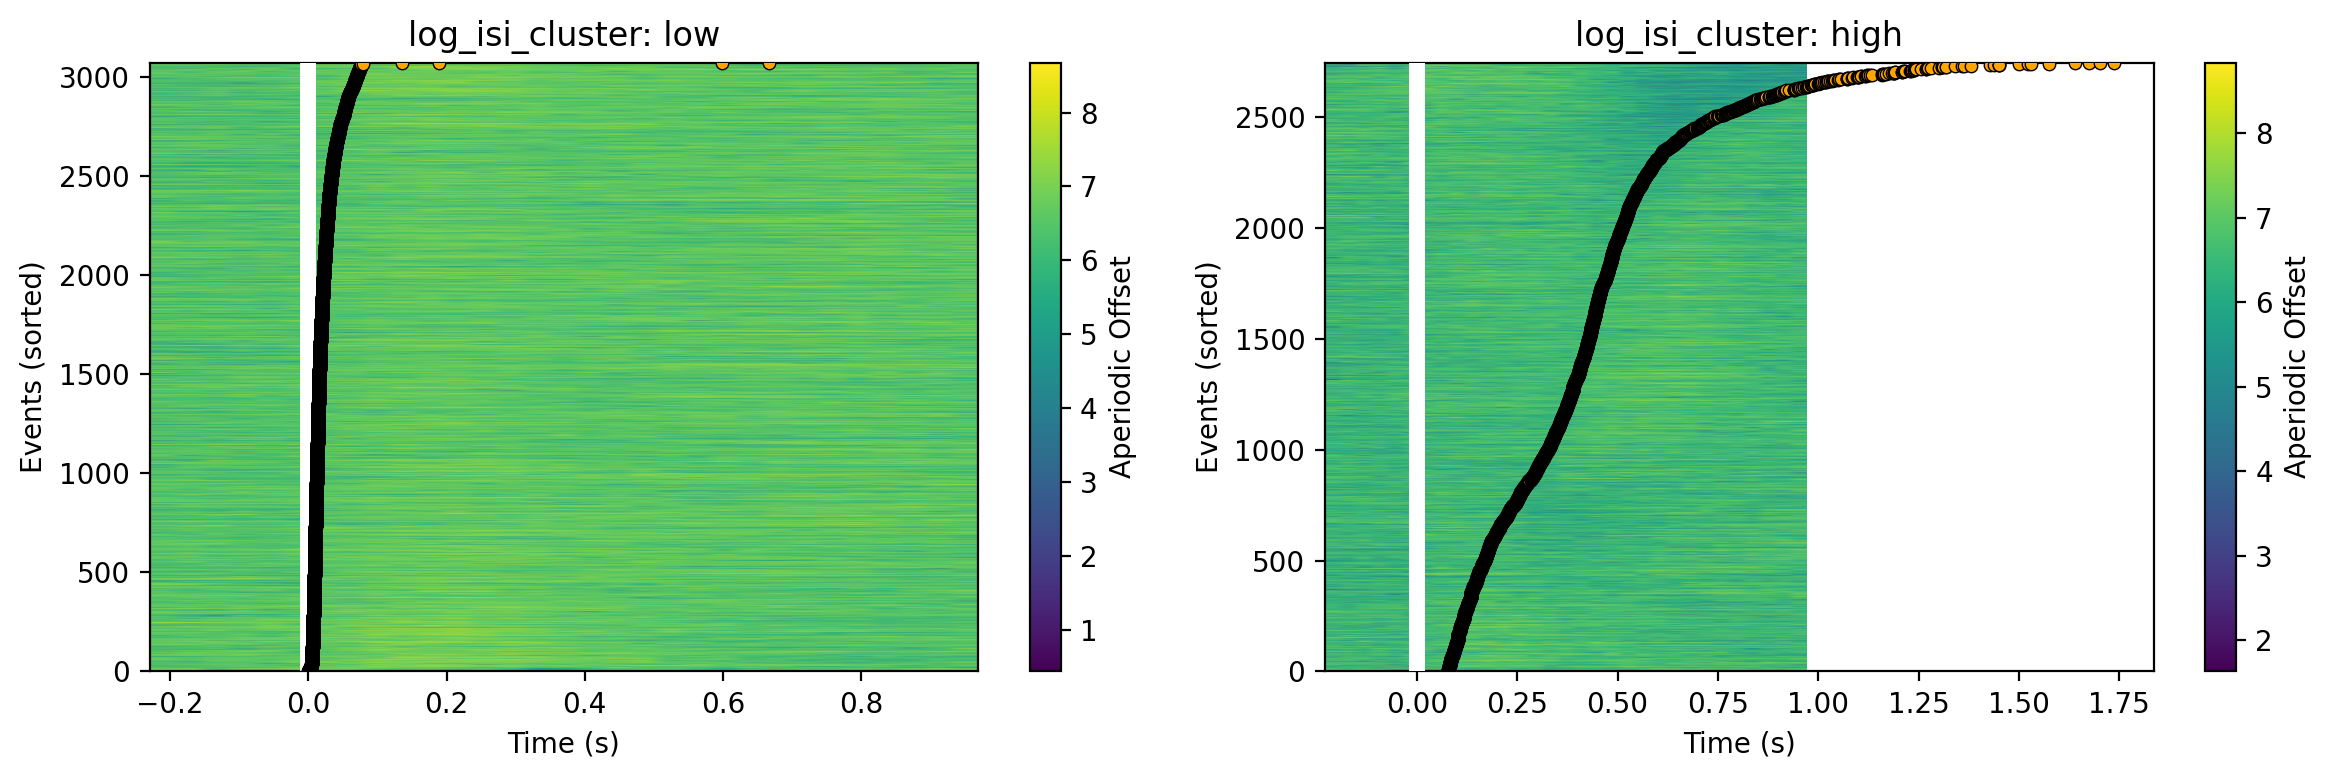

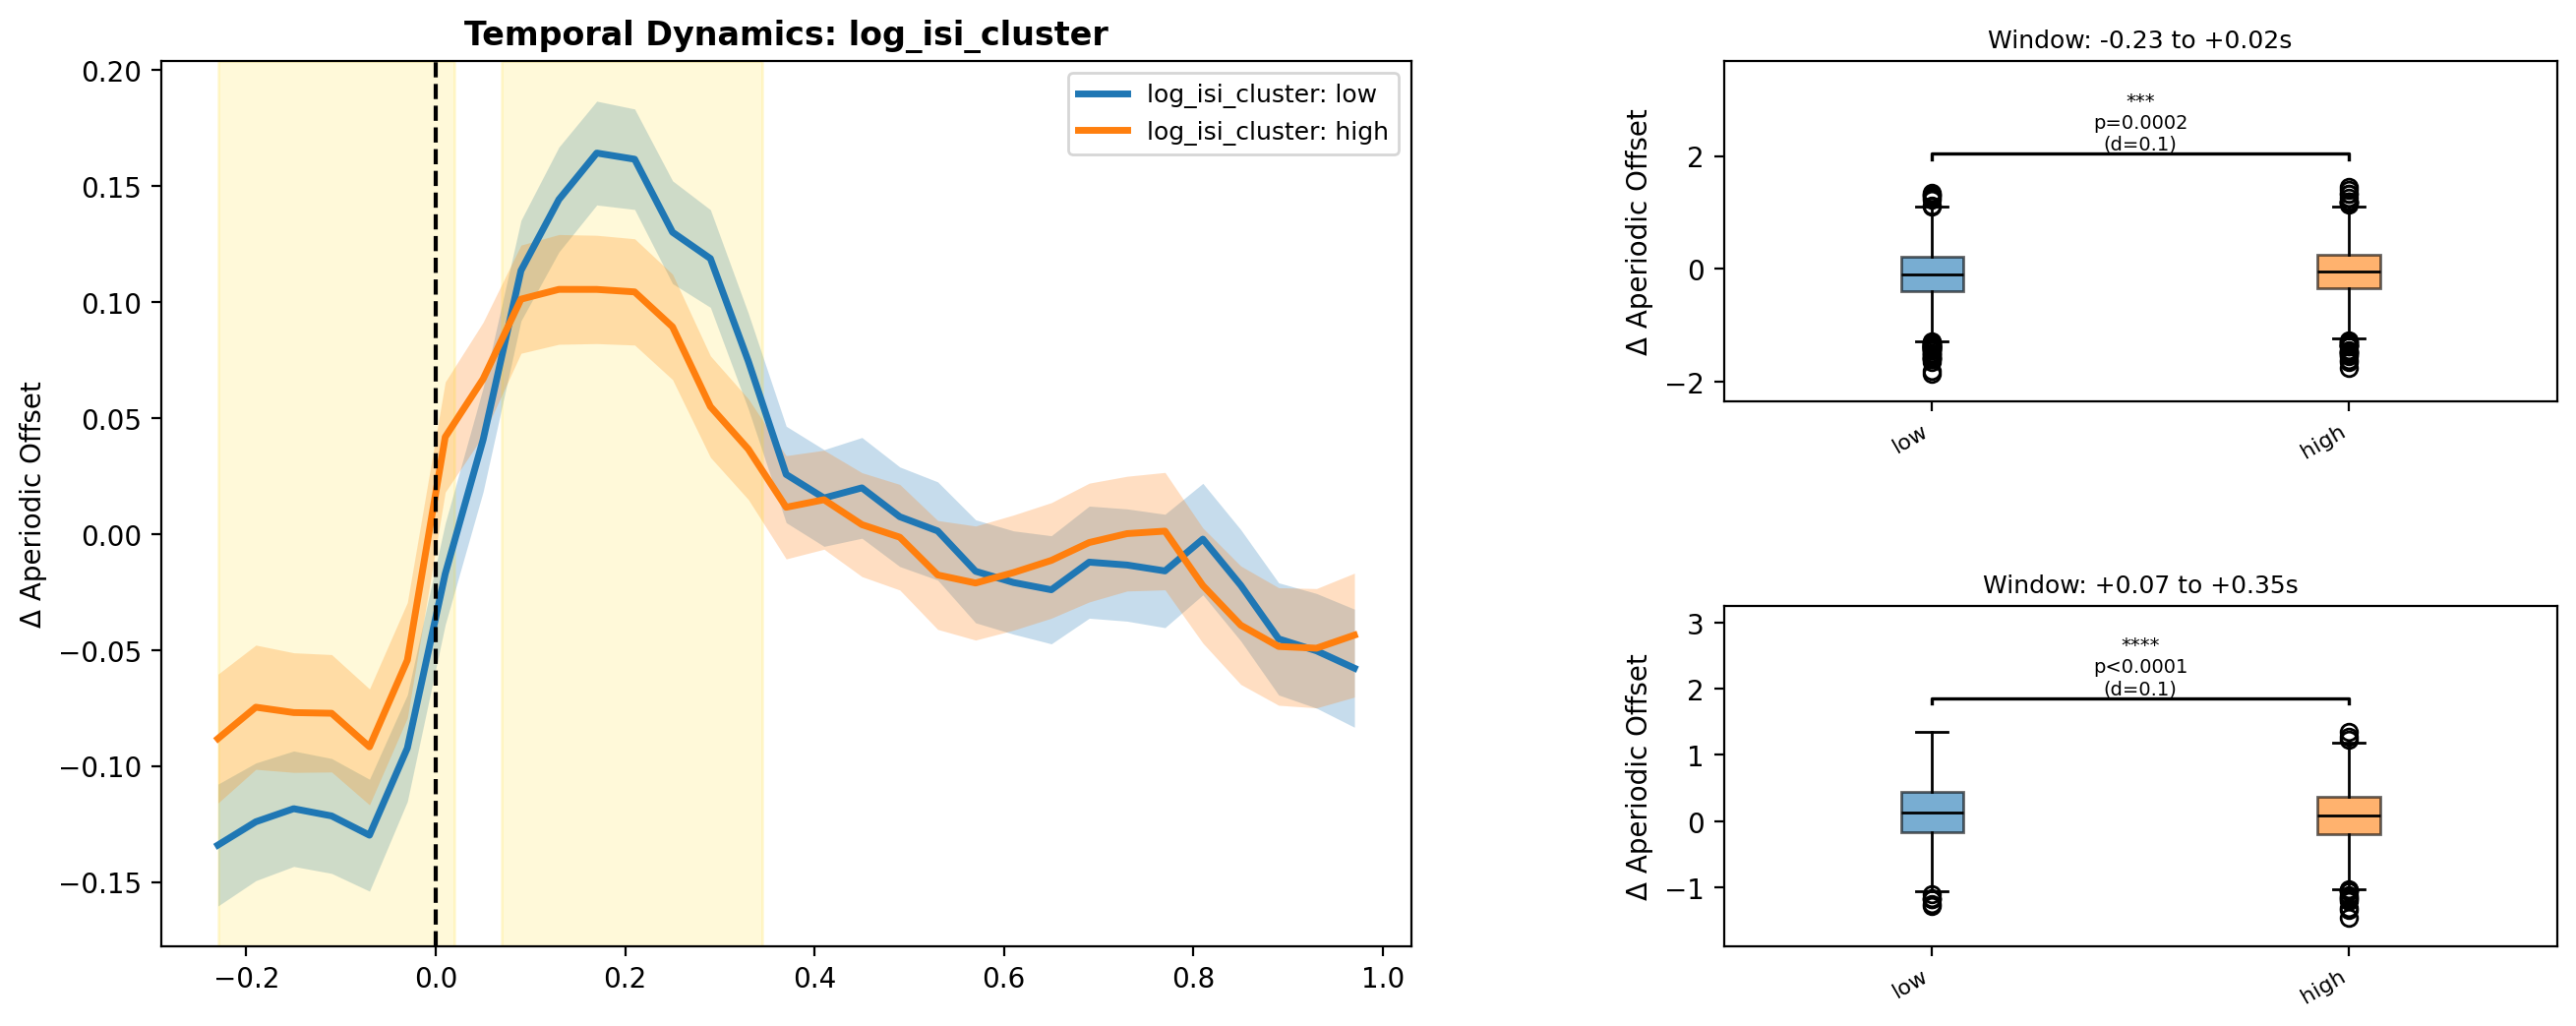

c26 features:  22%|██▏       | 2/9 [00:02<00:08,  1.21s/feat]
  RUNNING PIPELINE FOR: THETA AUC



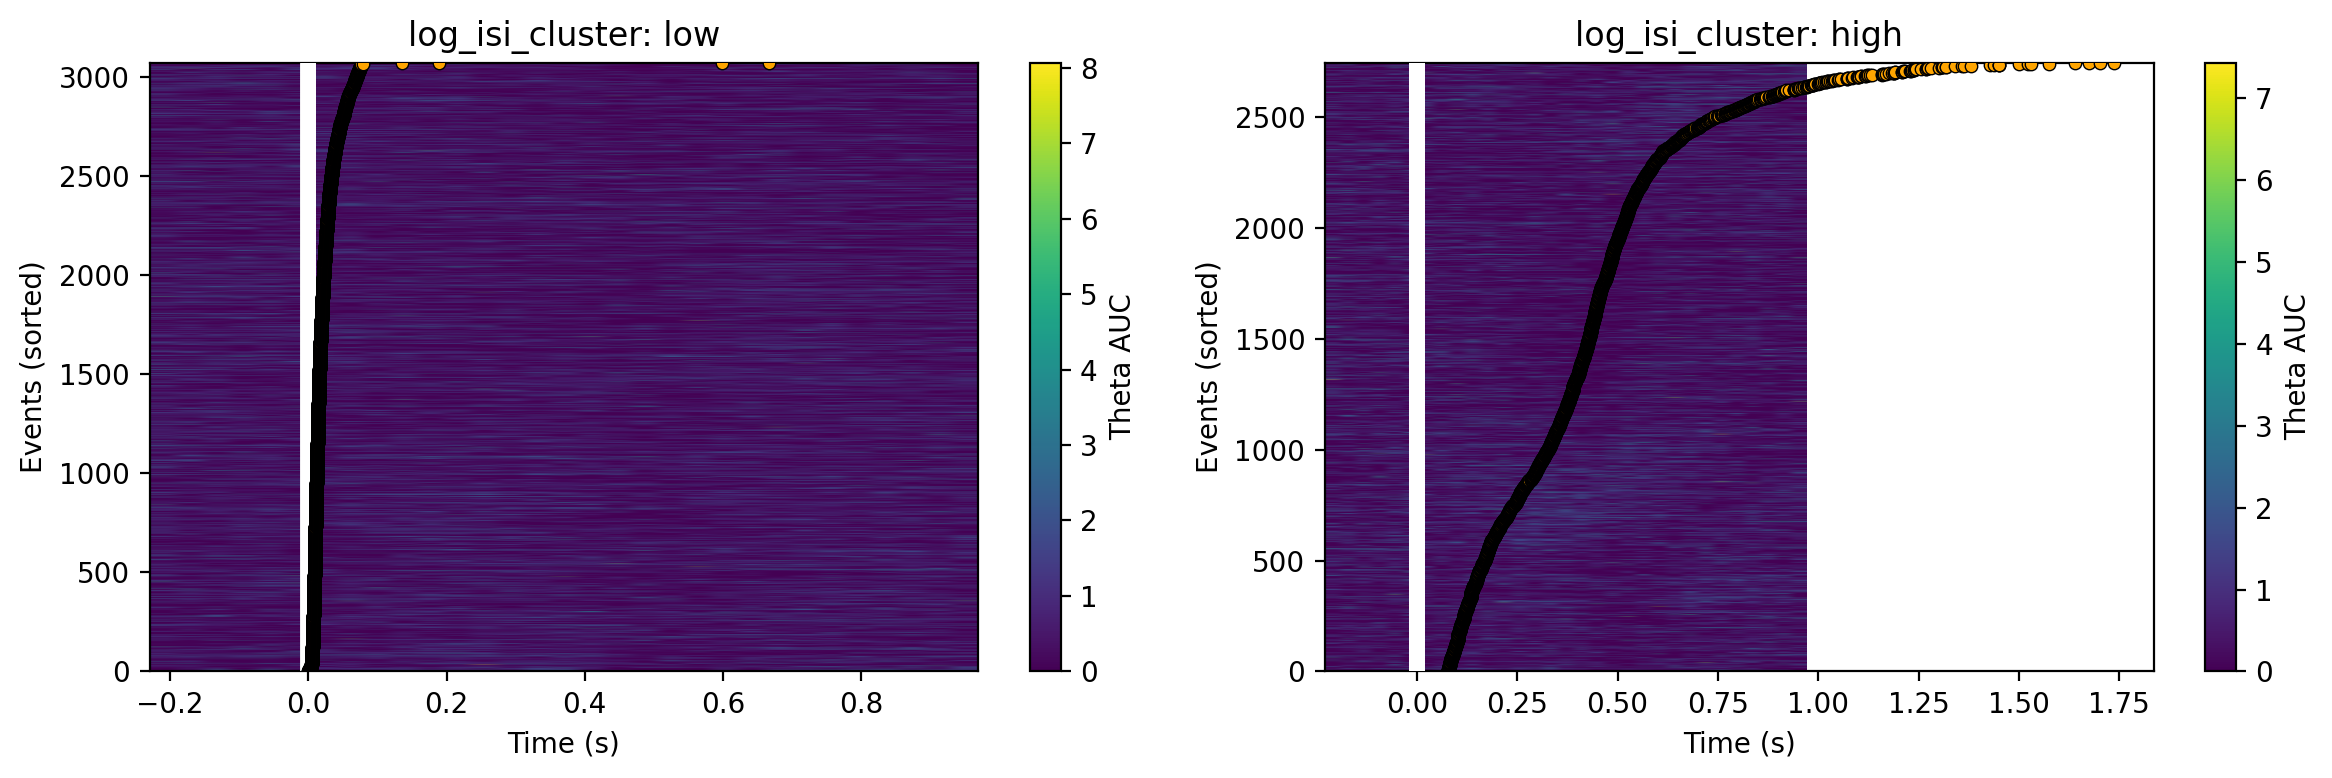

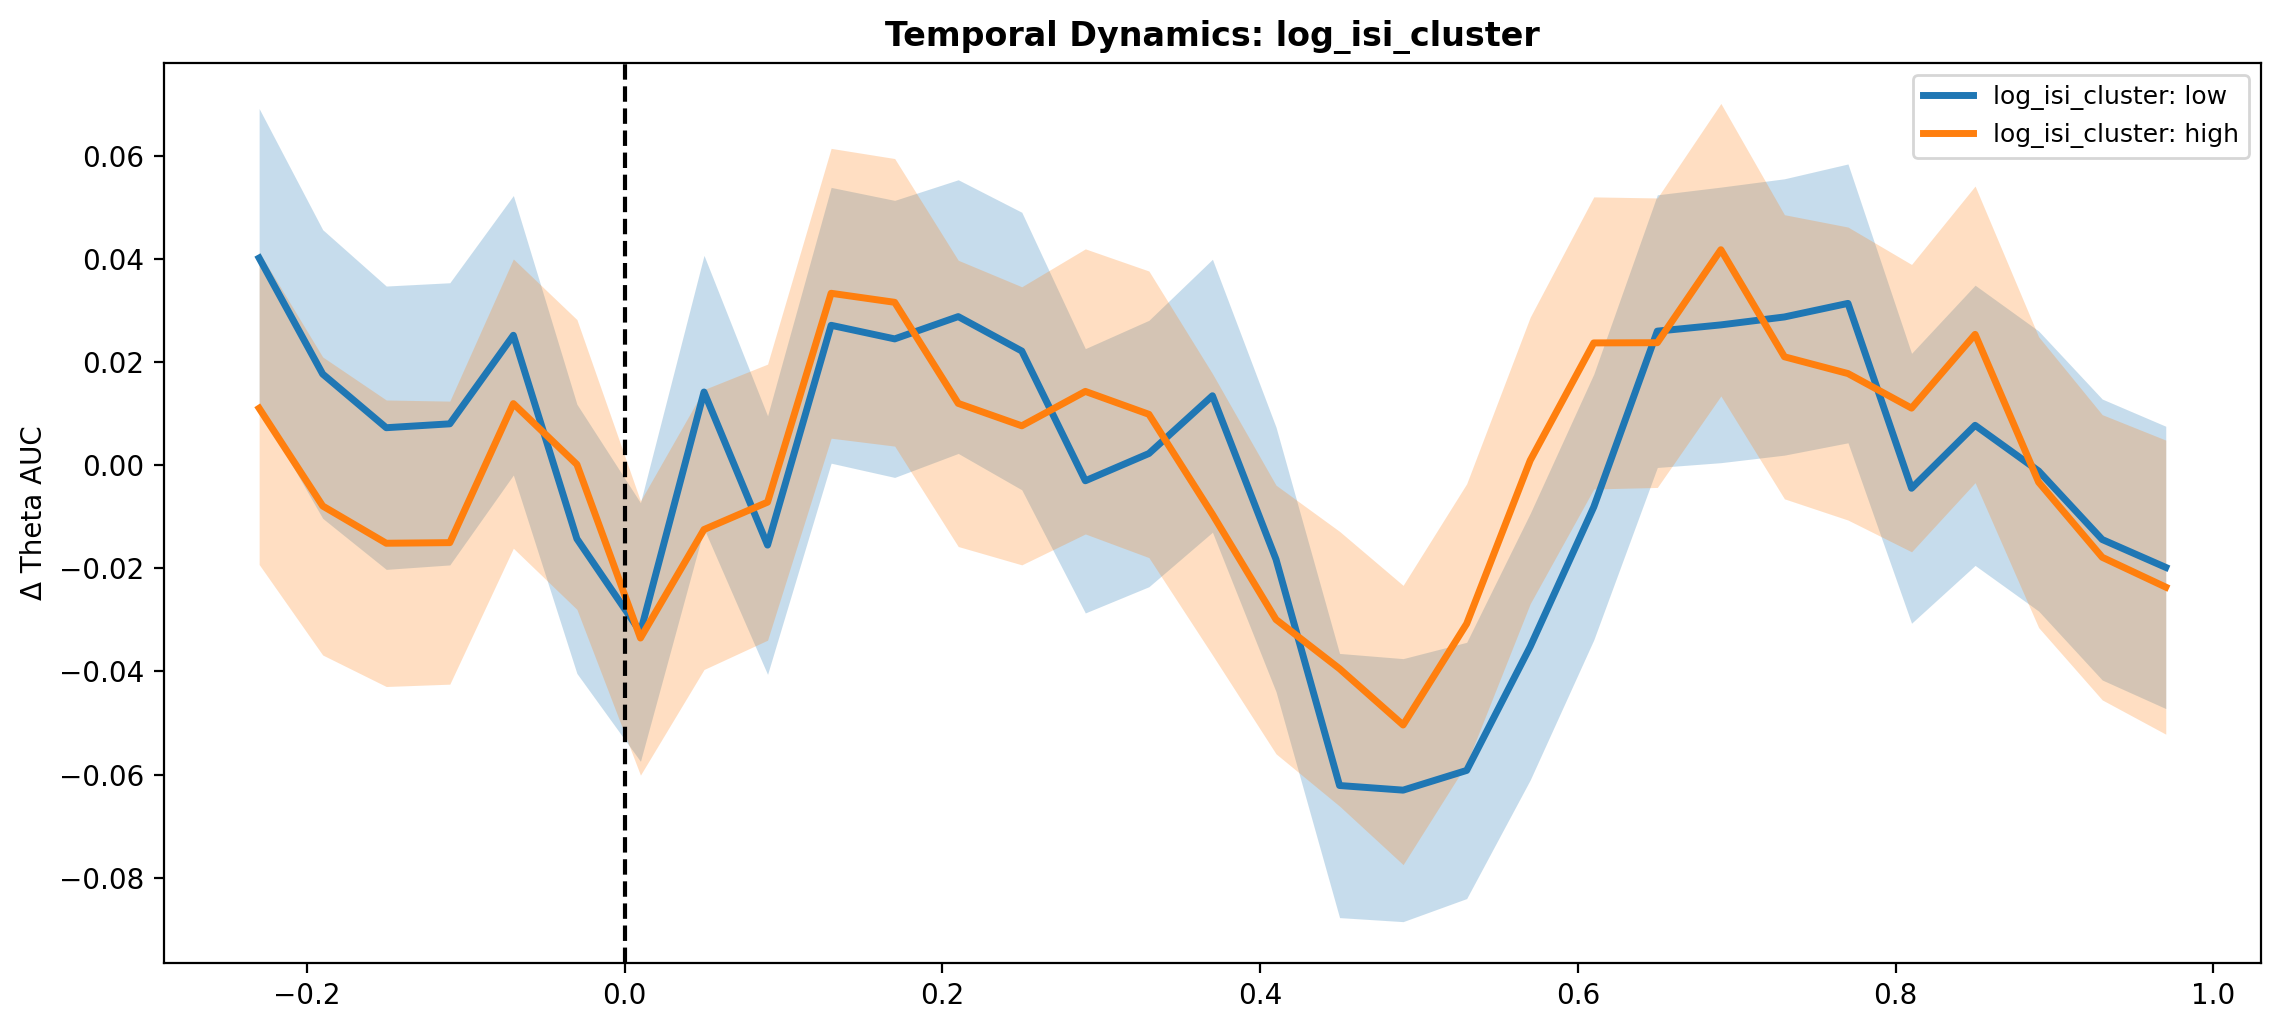

c26 features:  33%|███▎      | 3/9 [00:03<00:06,  1.11s/feat]
  RUNNING PIPELINE FOR: BETA AUC


  RUNNING PIPELINE FOR: GAMMA AUC



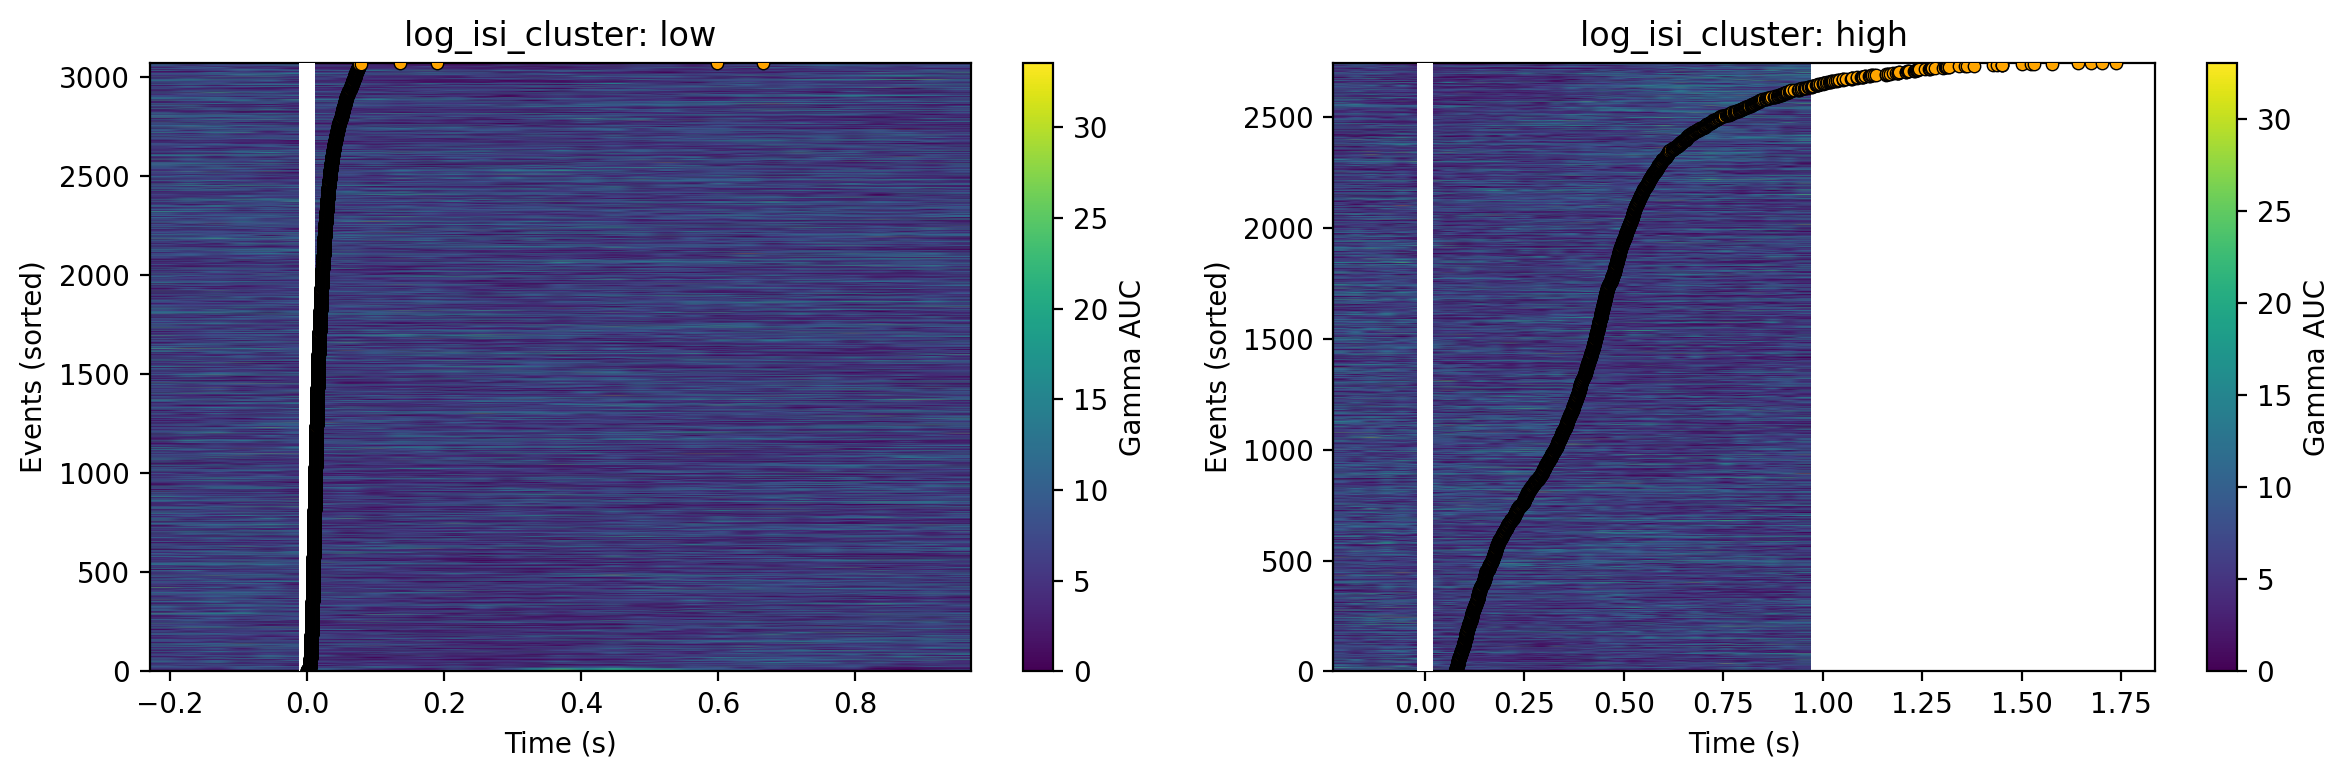

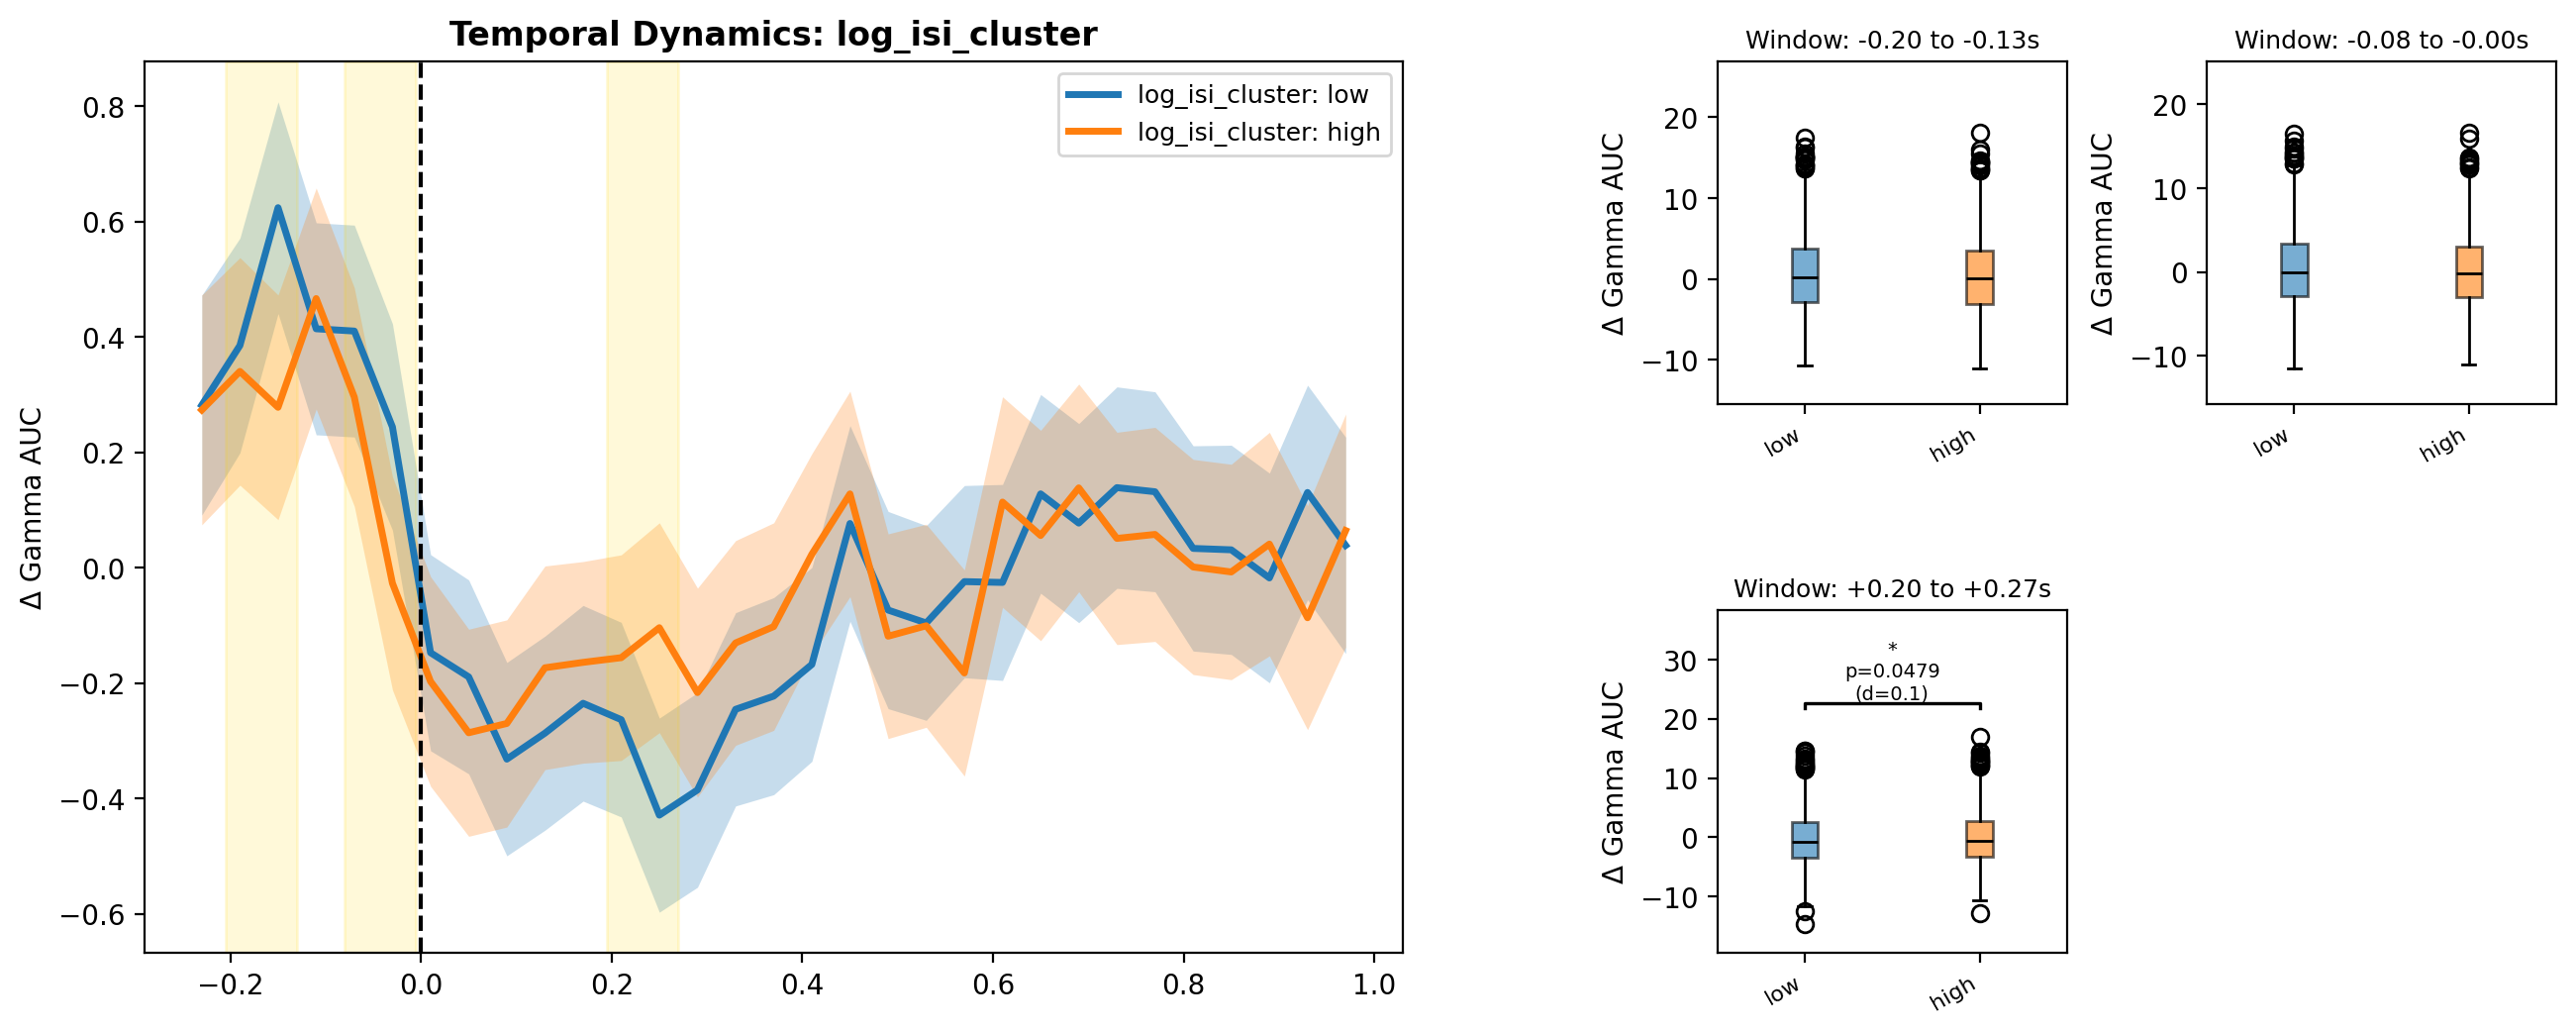

c26 features:  56%|█████▌    | 5/9 [00:04<00:03,  1.24feat/s]
  RUNNING PIPELINE FOR: R-SQUARED



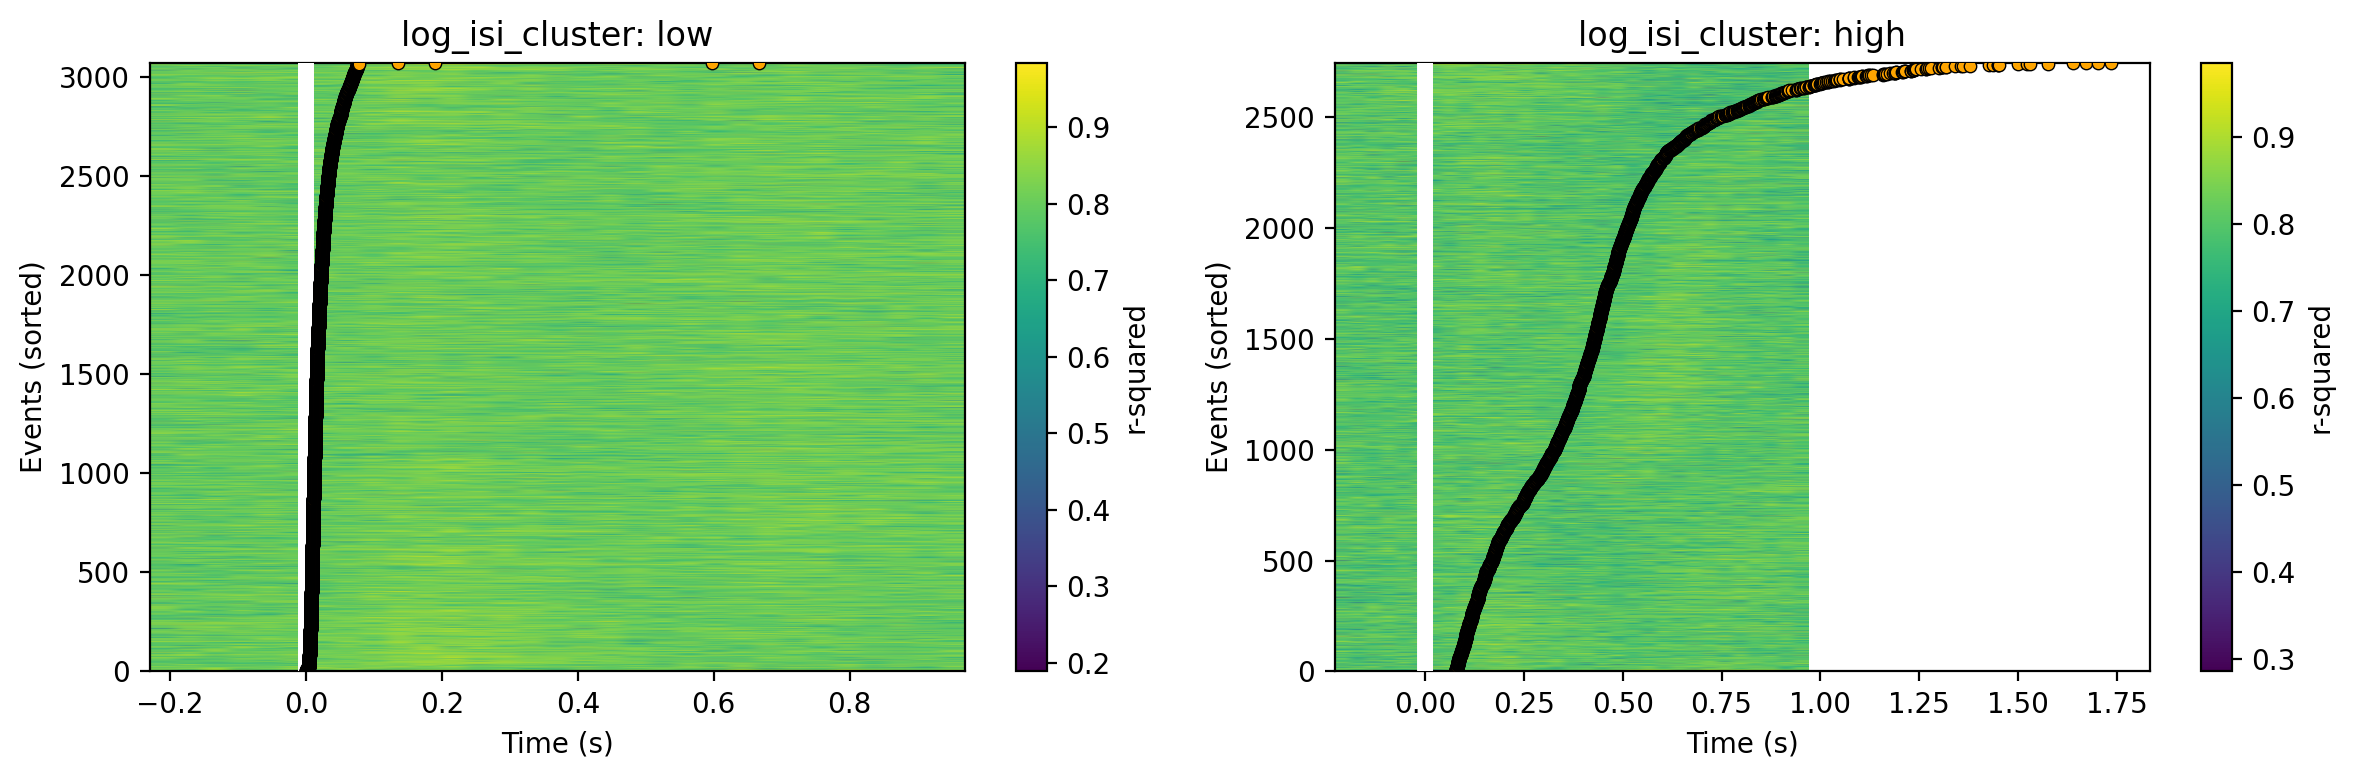

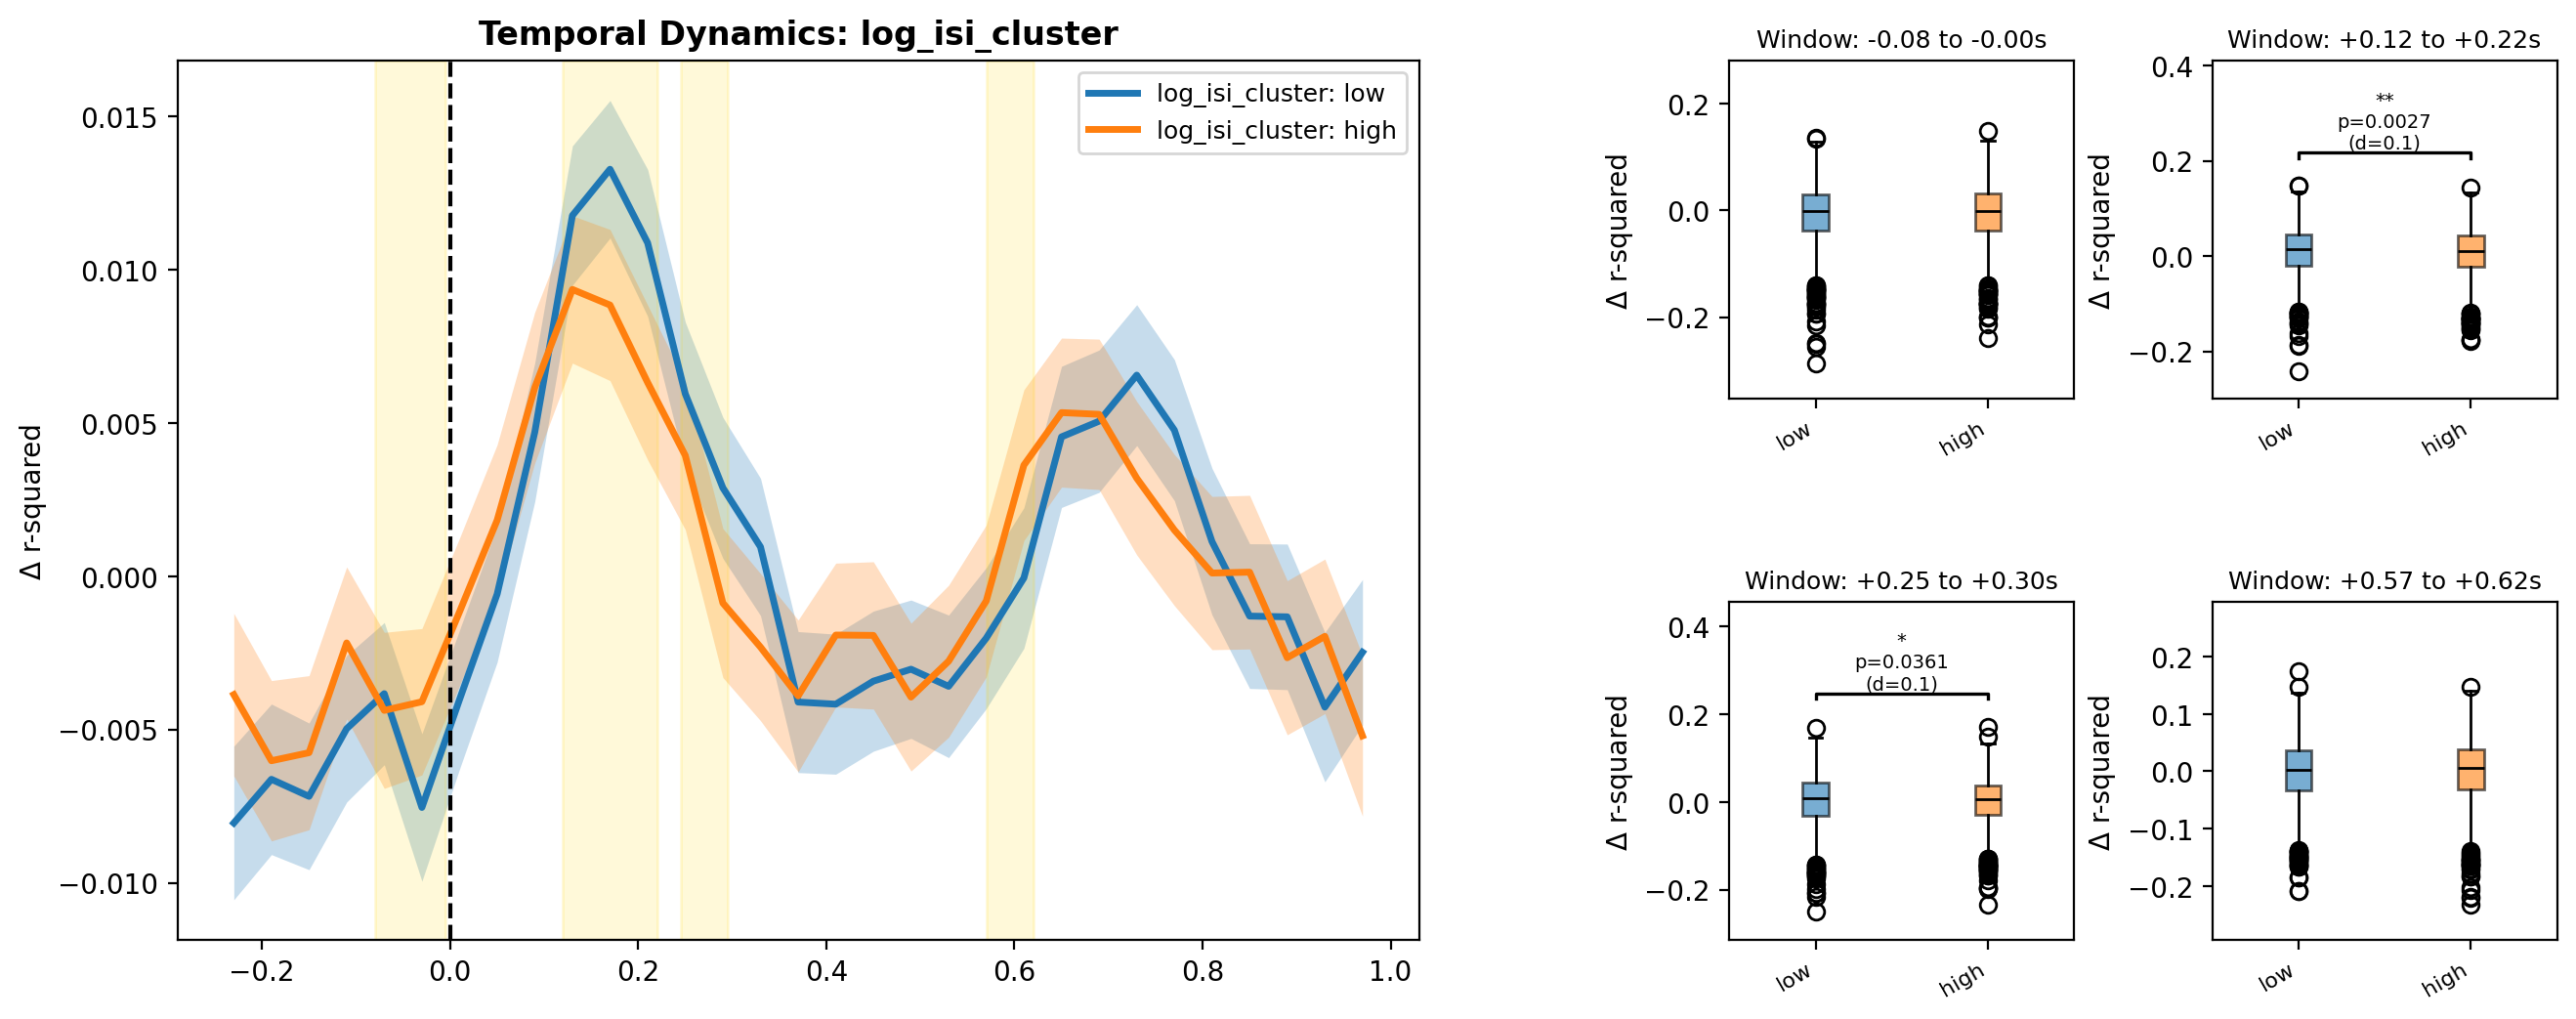

c26 features:  67%|██████▋   | 6/9 [00:06<00:02,  1.00feat/s]
  RUNNING PIPELINE FOR: LFP MEAN AMPLITUDE



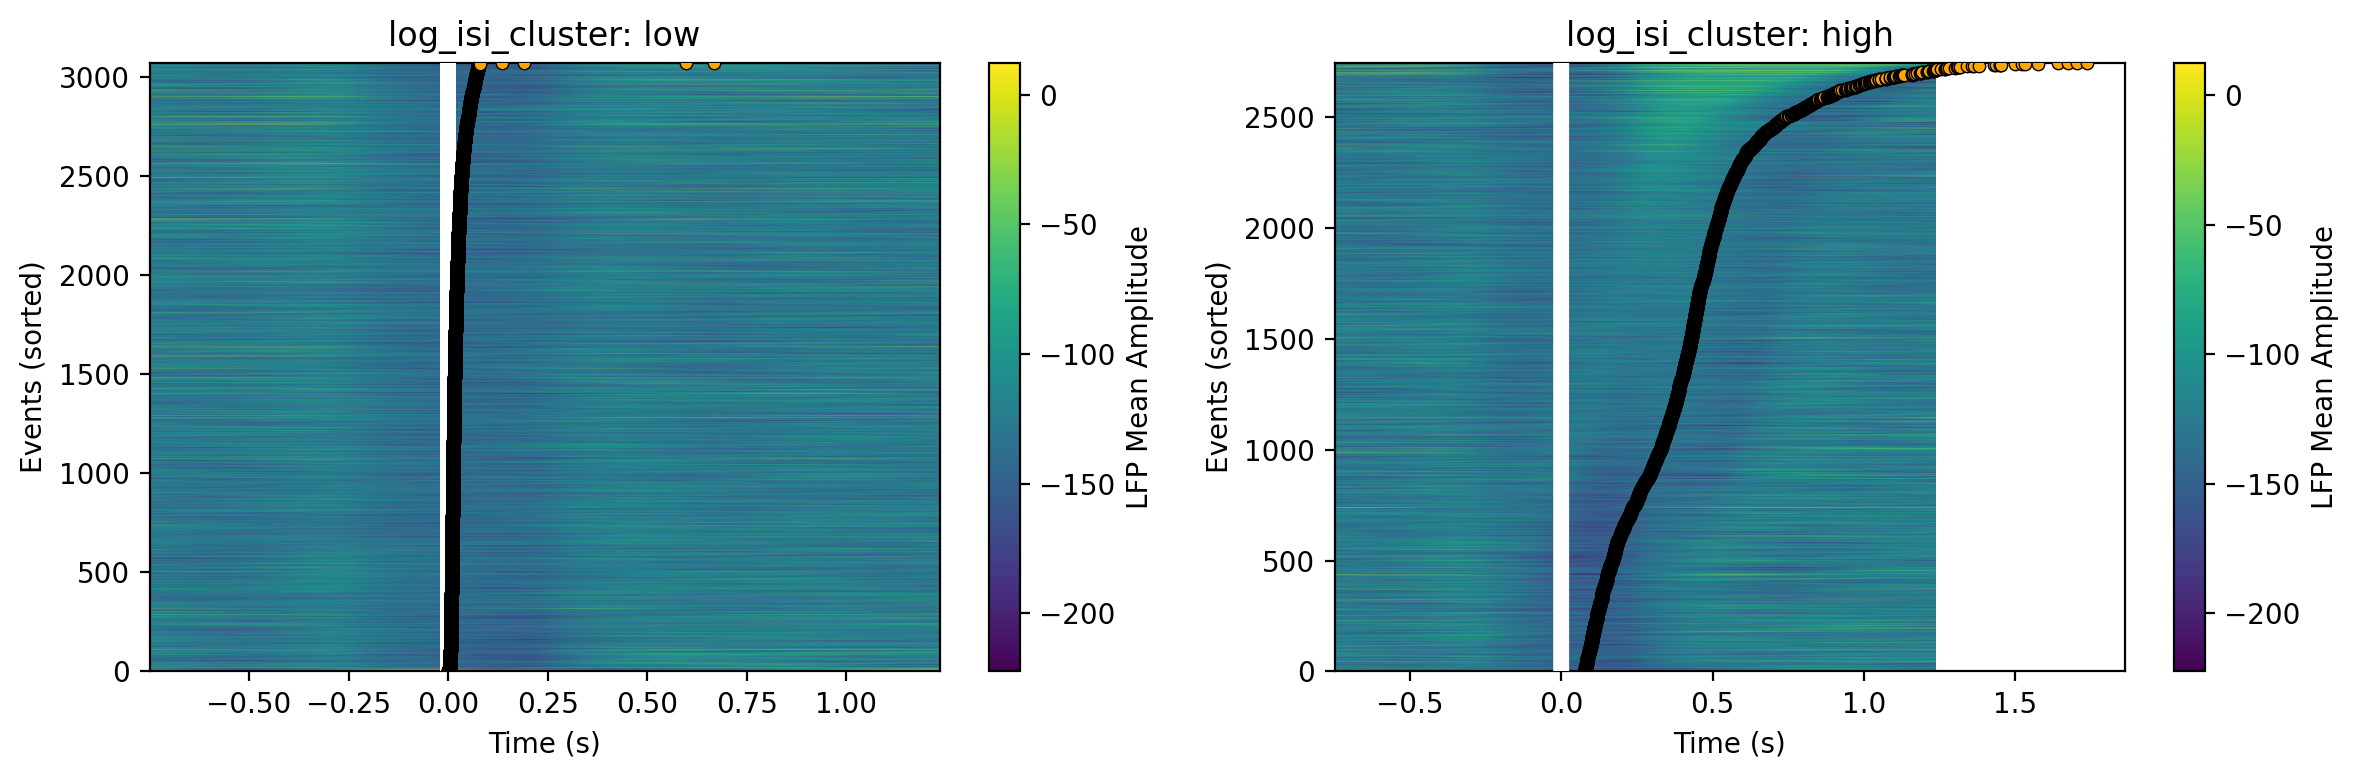

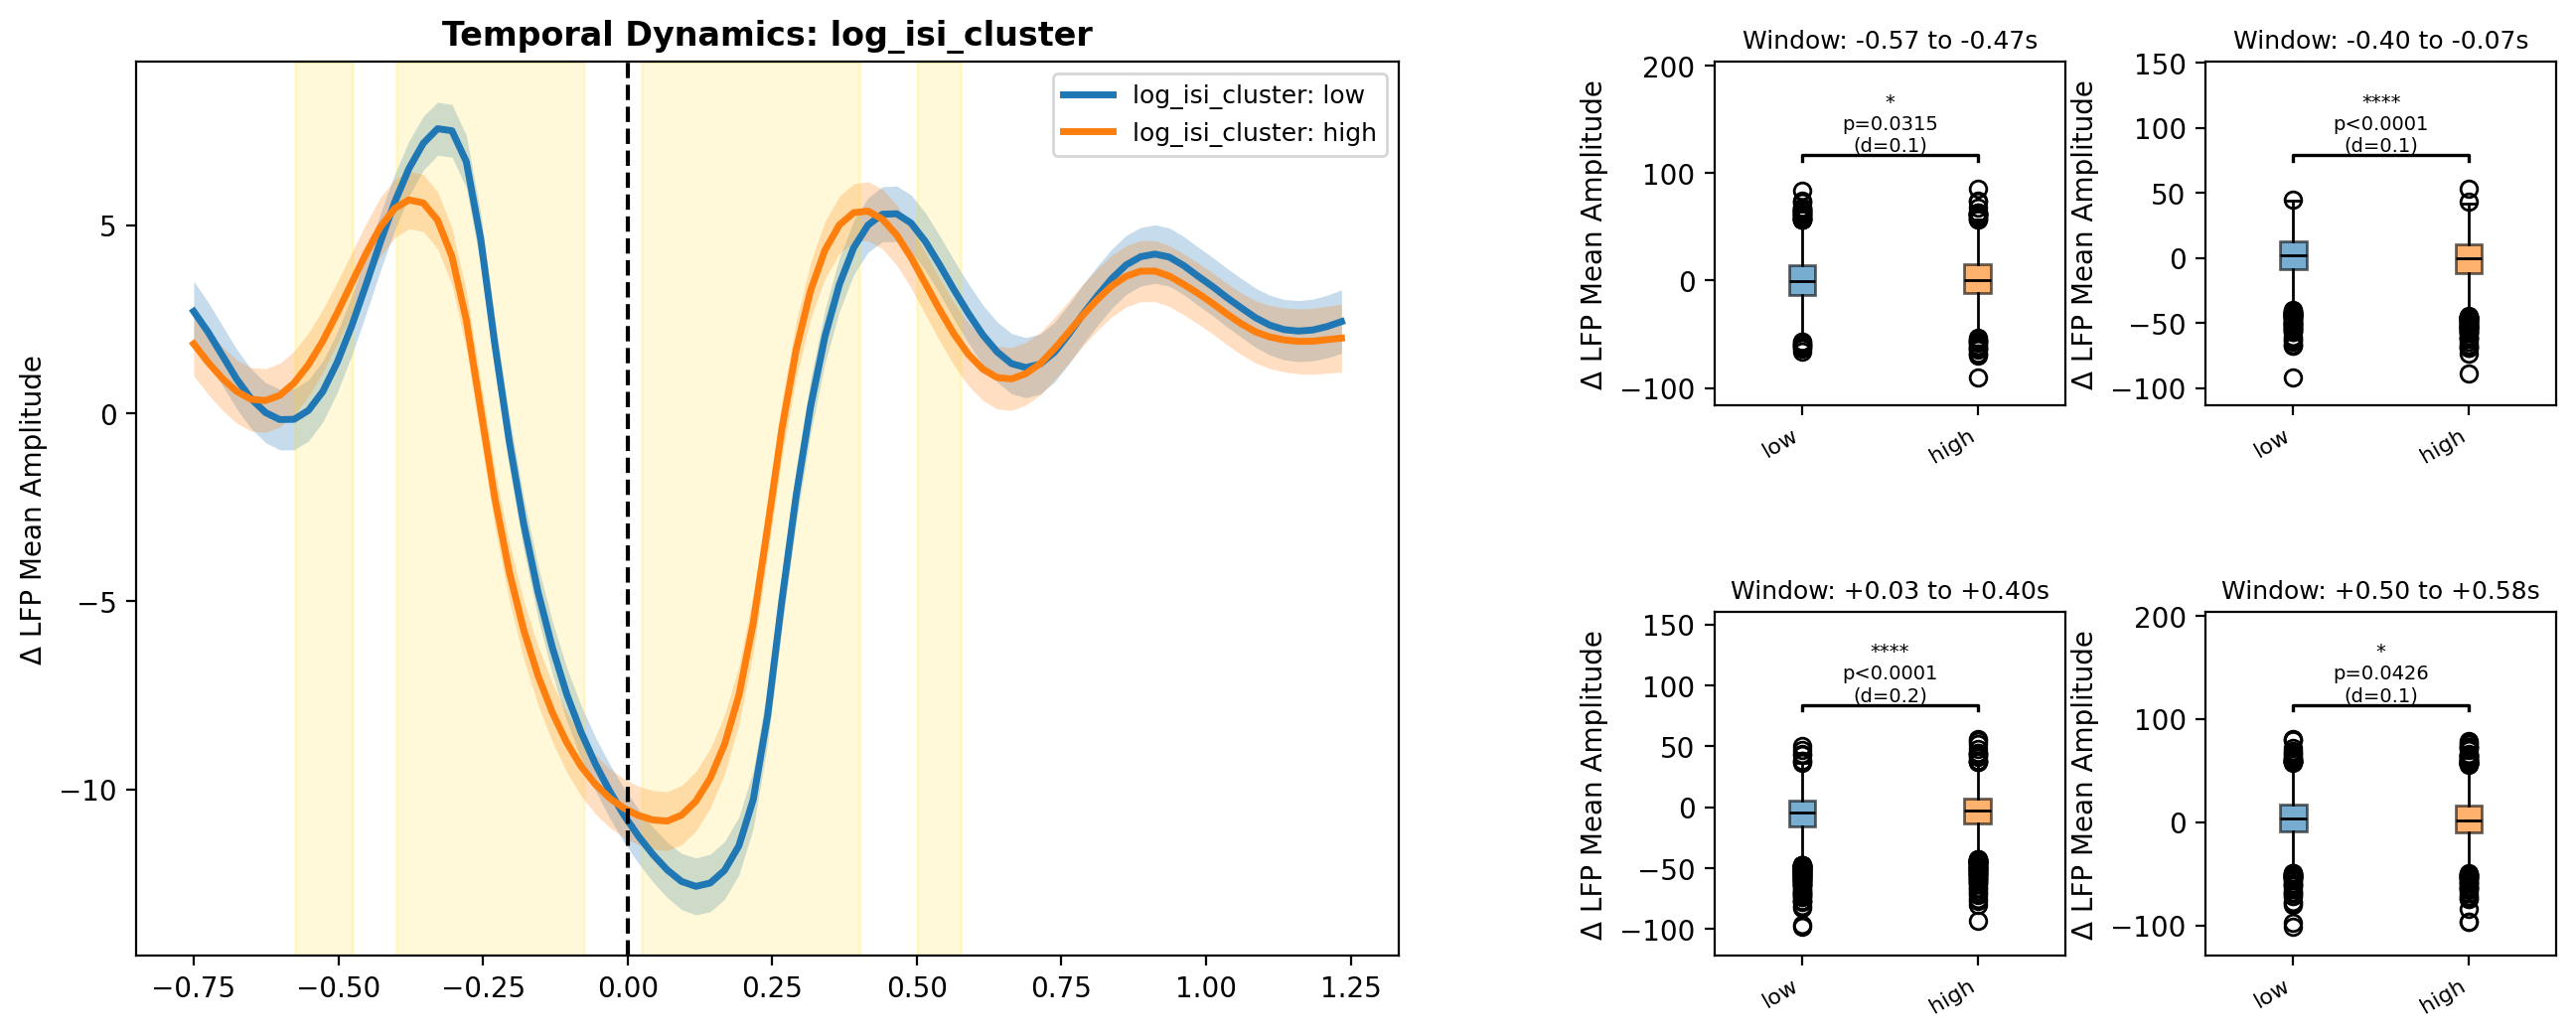

c26 features:  78%|███████▊  | 7/9 [00:07<00:02,  1.06s/feat]
  RUNNING PIPELINE FOR: LFP STD



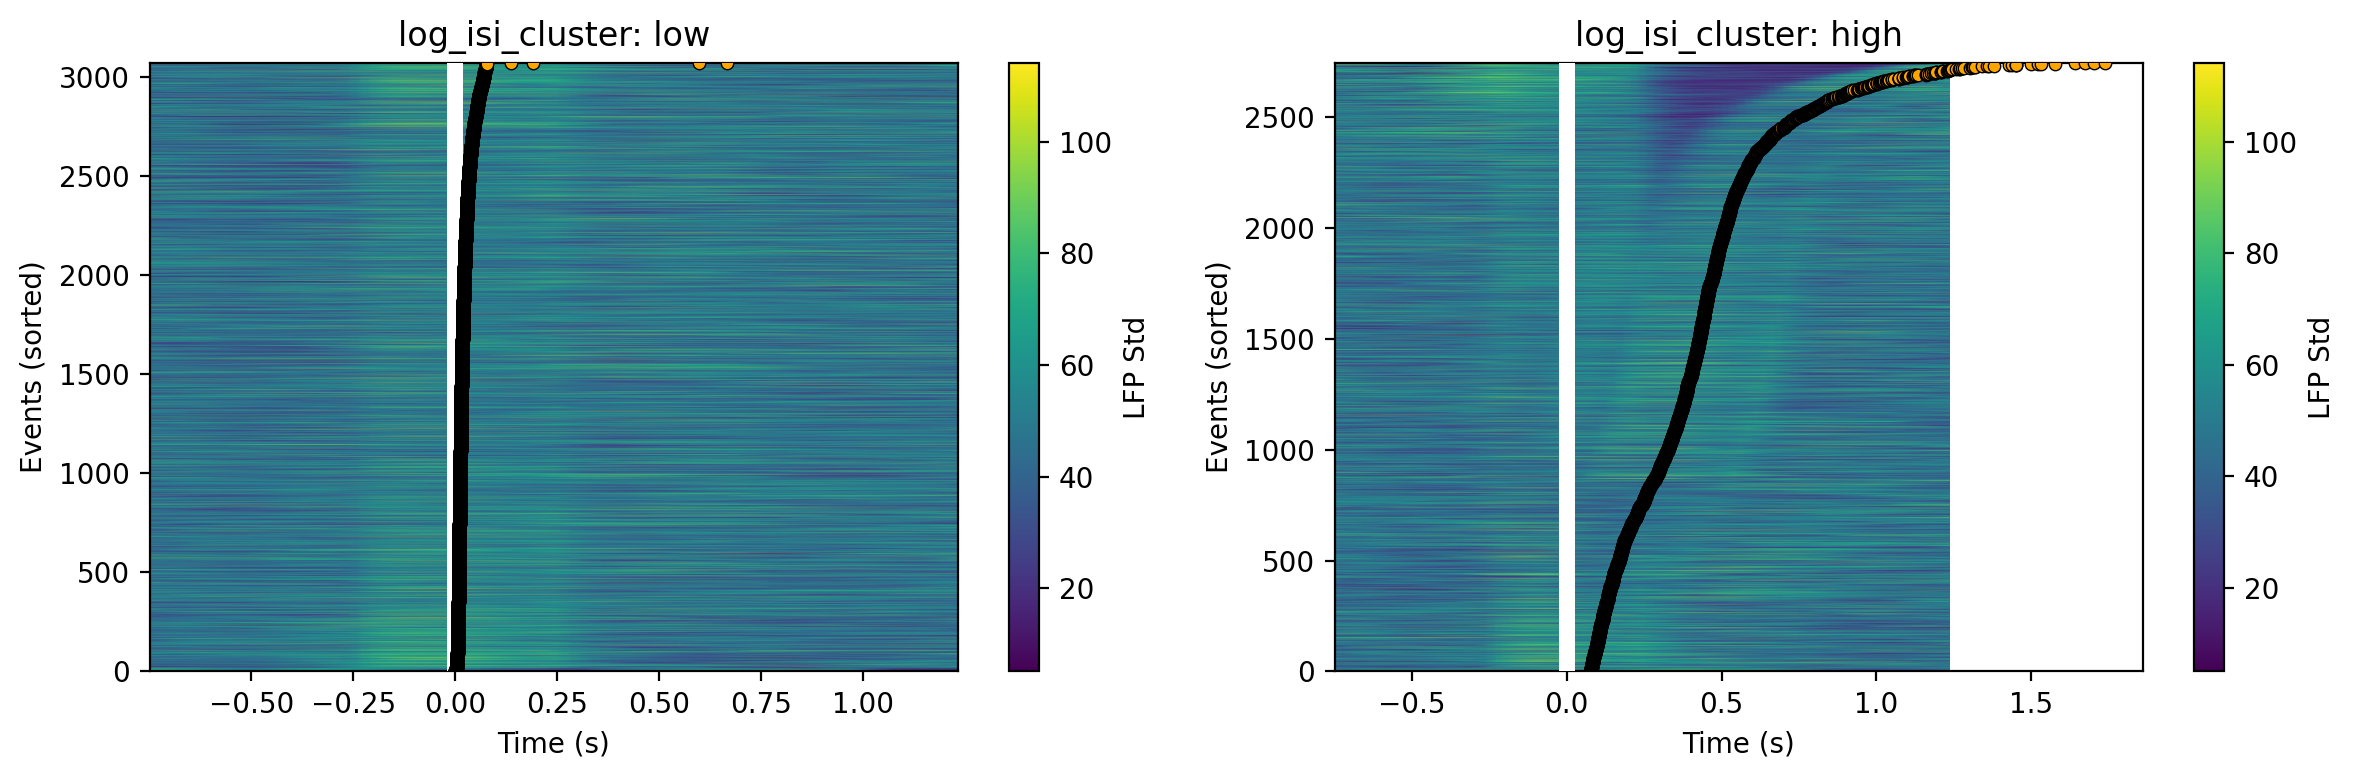

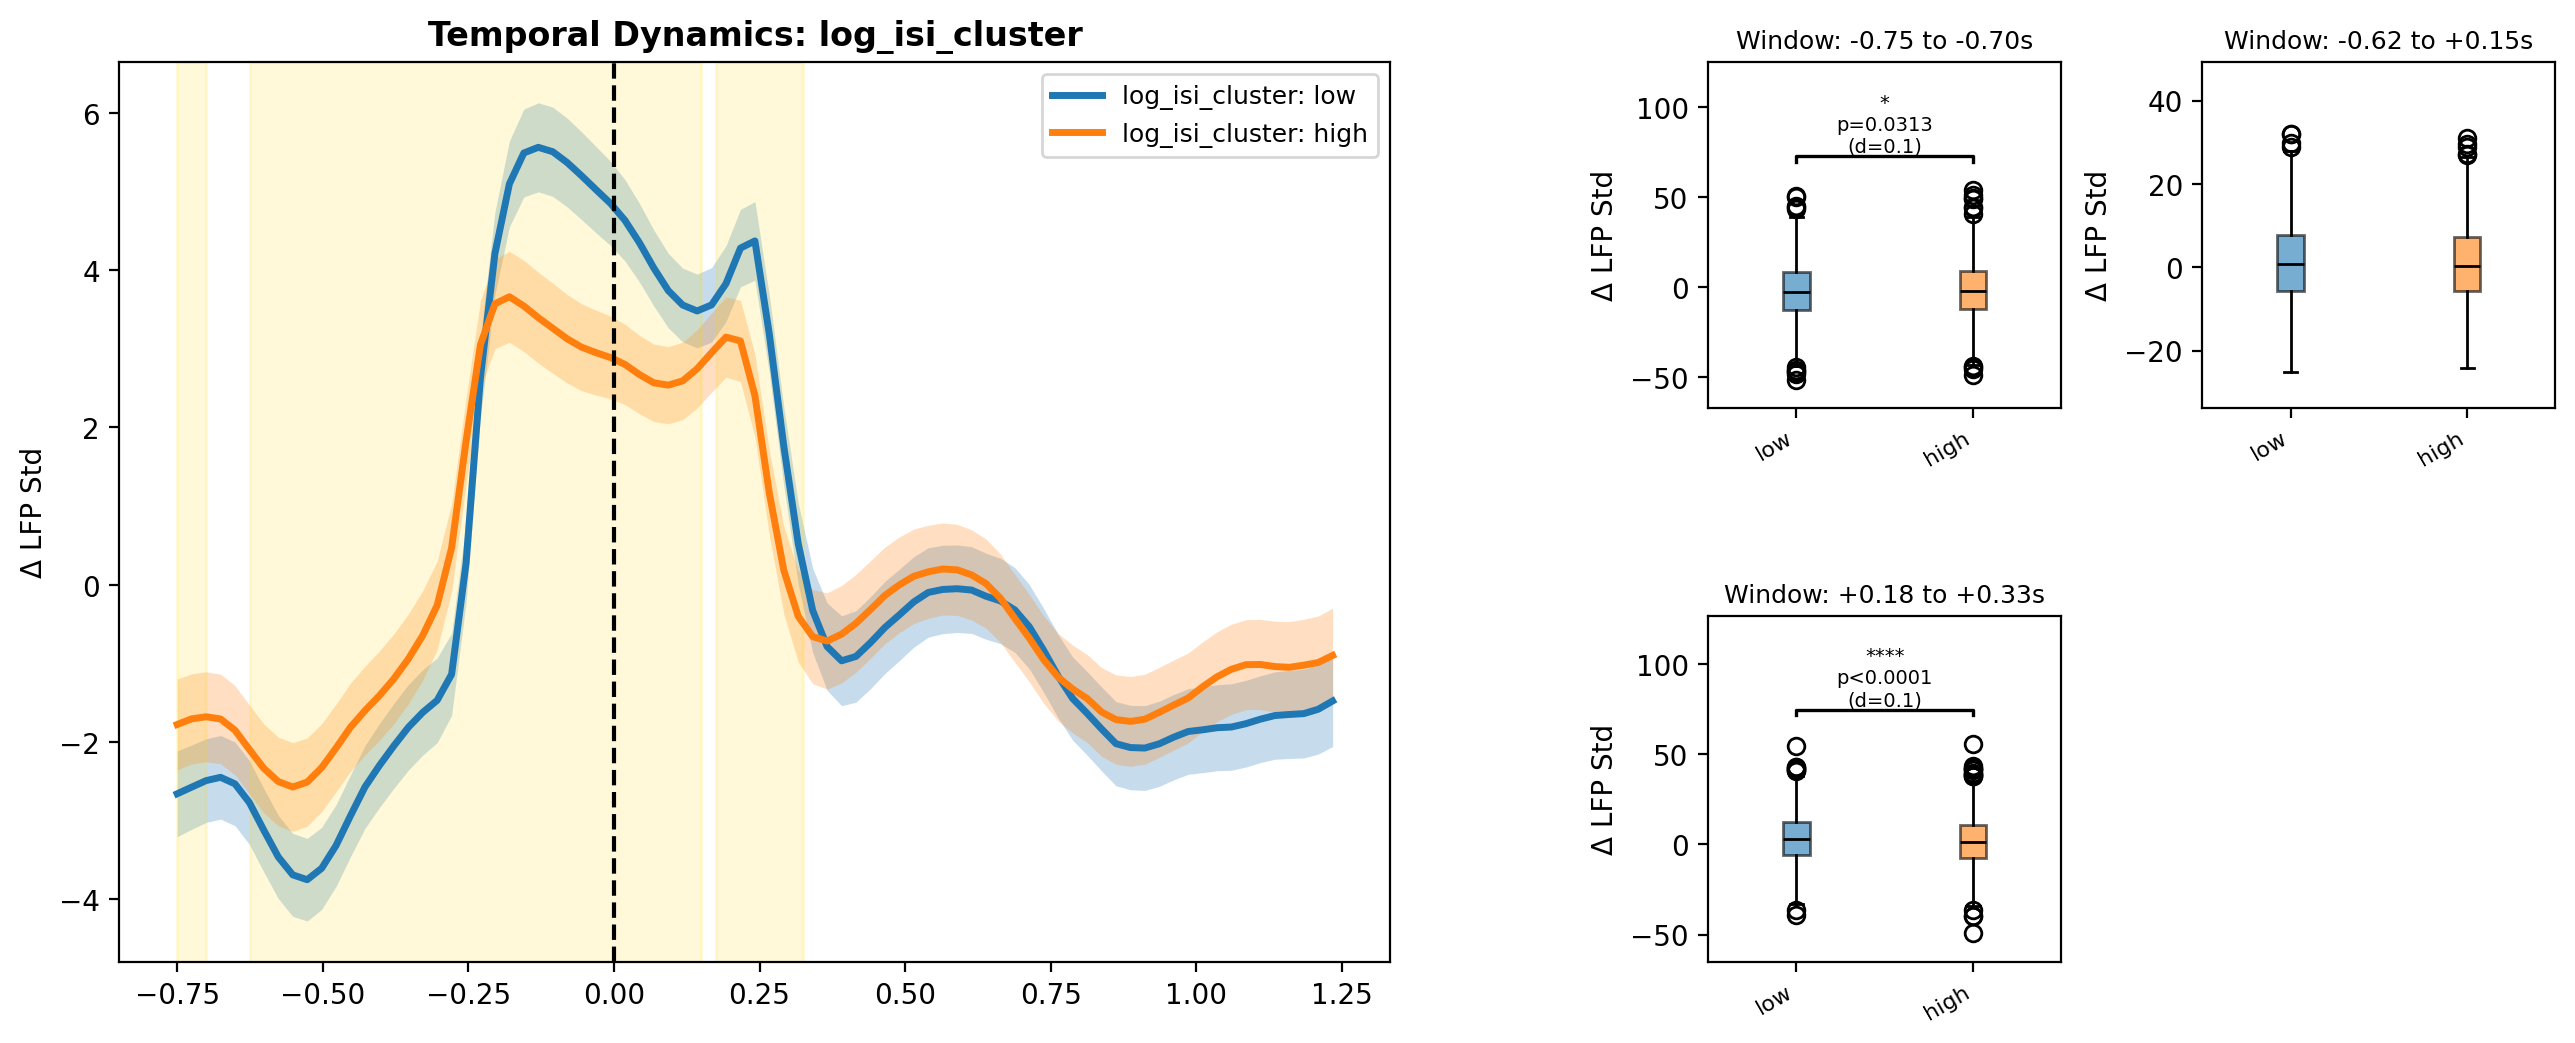

c26 features:  89%|████████▉ | 8/9 [00:08<00:01,  1.08s/feat]
  RUNNING PIPELINE FOR: LFP SPECTRAL EXPONENT



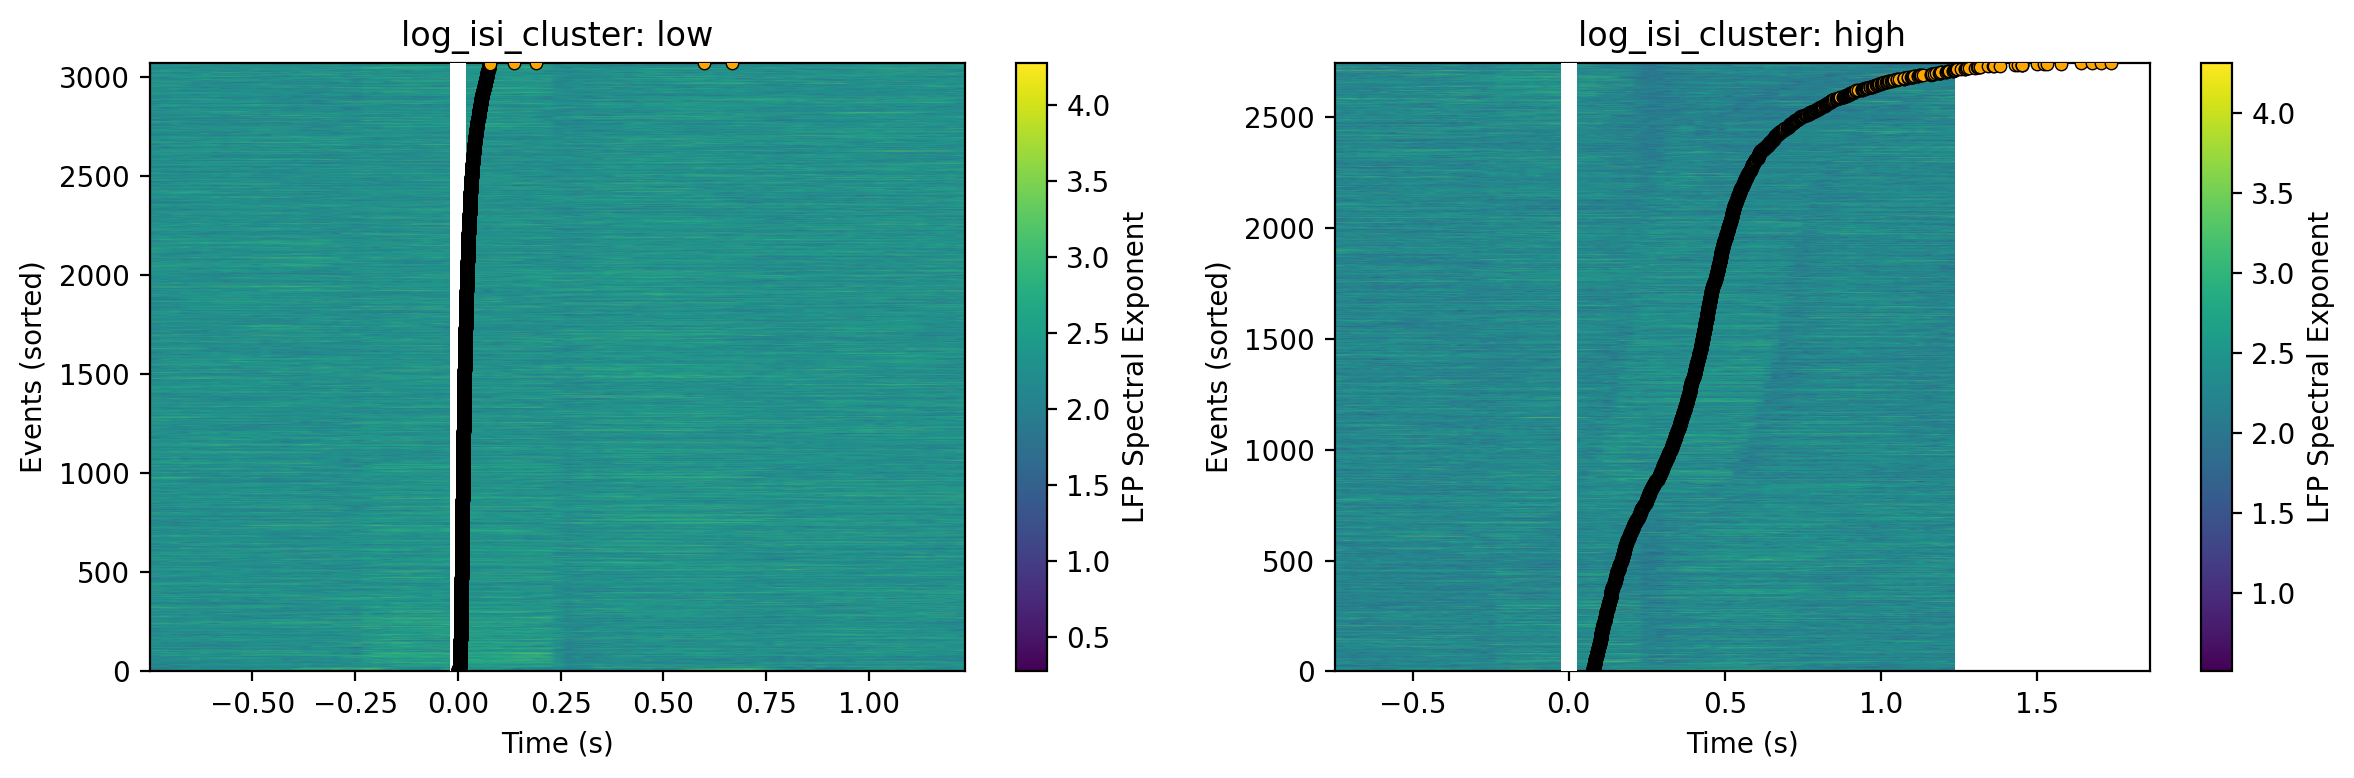

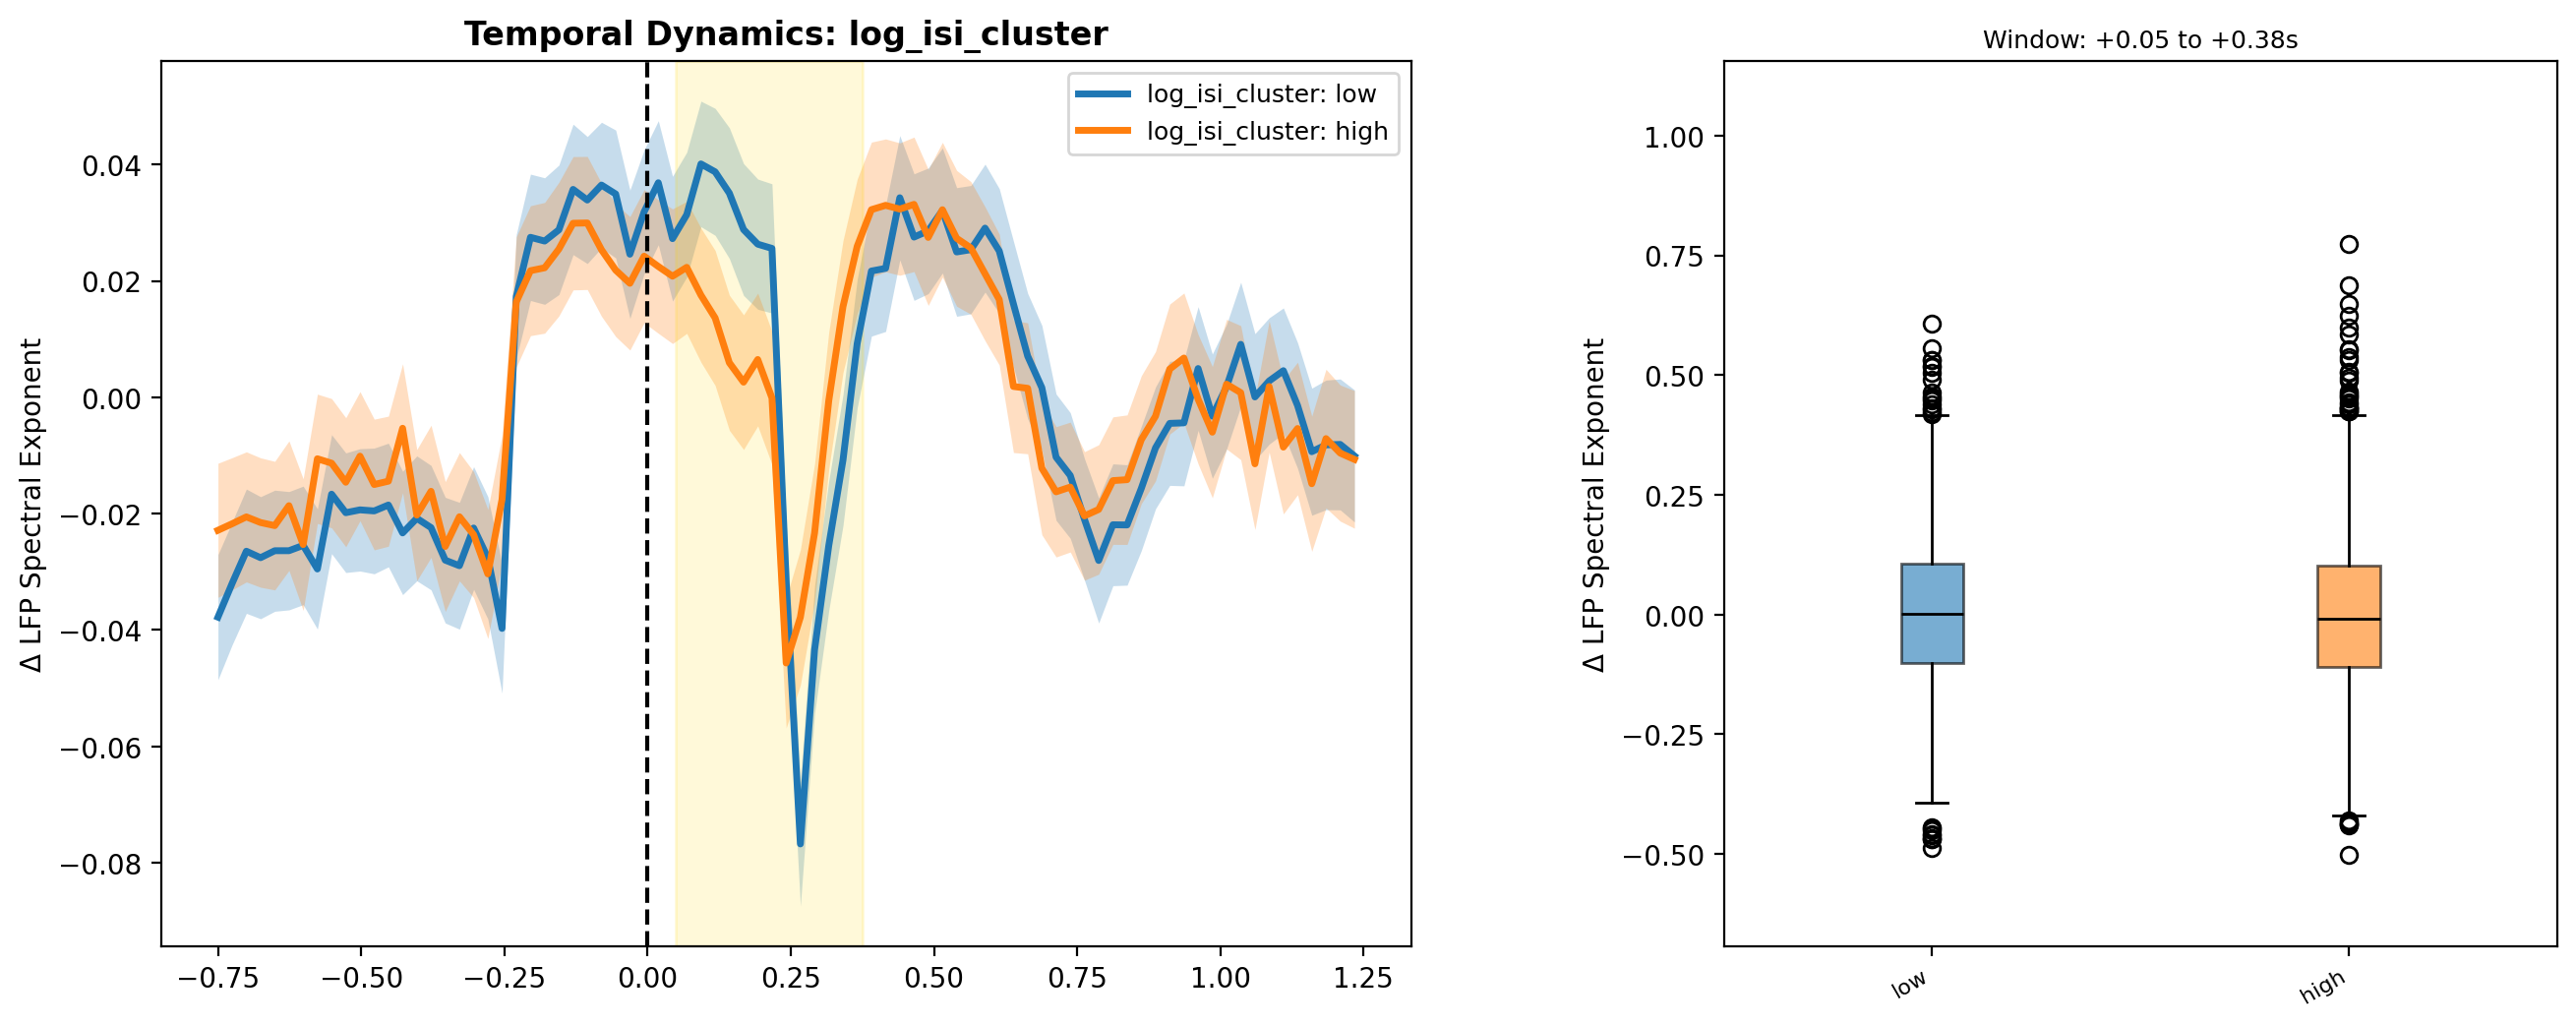

c26 features: 100%|██████████| 9/9 [00:09<00:00,  1.06s/feat]

  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/c26_sliding_stats.pkl
  Saved: /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/lfp_spk_group_pickles/c26_per_spike_data.pkl


In [7]:
# Sliding-window LFP–spike group analysis
features_list = [
    {"feature": "exponent",     "label": "Aperiodic Exponent"},
    {"feature": "offset",       "label": "Aperiodic Offset"},
    {"feature": "band",  "band": "theta",  "label": "Theta AUC"},
    {"feature": "band",  "band": "beta",   "label": "Beta AUC"},
    {"feature": "band",  "band": "gamma",  "label": "Gamma AUC"},
    {"feature": "r_squared",    "label": "r-squared"},
    {"feature": "lfp_mean",     "label": "LFP Mean Amplitude"},
    {"feature": "lfp_std",      "label": "LFP Std"},
    {"feature": "lfp_exponent", "label": "LFP Spectral Exponent"},
]

stats_pickle = os.path.join(SPE1_PICKLE_ROOT, 'lfp_spk_group_pickles', f'c{cell_num}_sliding_stats.pkl')

master_results = run_master_LFP_spk_analysis(
    cell_id             = f"c{cell_num}",
    specparam_by_spike  = specparam_by_spike,
    groups              = groups,
    features_to_analyze = features_list,
    lfp_windows_by_spike= lfp_windows_by_spike,
    save_dir            = os.path.dirname(stats_pickle),
    force_recompute     = FORCE_STATS,
    plot                = True,
)

## 4. Spectra at Significant Windows

In [8]:
plot_significant_windows_spectra(df_features_clust, specparam_by_spike, master_results)


log_isi_cluster: plotting 15 most significant windows (of 15 total)
  Extracting window 0.025s – 0.400s  (d=0.162)


  Extracting window -0.400s – -0.075s  (d=0.148)


  Extracting window 0.070s – 0.295s  (d=0.125)


  Extracting window 0.070s – 0.345s  (d=0.105)


  Extracting window 0.175s – 0.325s  (d=0.104)


...

  Extracting window -0.575s – -0.475s  (d=0.056)


  Extracting window 0.245s – 0.295s  (d=0.055)


  Extracting window 0.500s – 0.575s  (d=0.053)


  Extracting window 0.195s – 0.270s  (d=0.052)


Box(children=(Output(),), layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_r…

## 5. Pre / Post Spike Specparam Comparison

Extracting pre/post means: 100%|██████████| 5818/5818 [00:02<00:00, 2381.10it/s]
  Note: aligning df (5824 spikes) → specparam (5818 spikes); 6 edge spikes dropped.


/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_analysis.py:4708: RuntimeWarning: Mean of empty slice
  pre_m  = np.nanmean(pre_vals[fk][idx])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_analysis.py:4709: RuntimeWarning: Mean of empty slice
  post_m = np.nanmean(post_vals[fk][idx])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_analysis.py:4708: RuntimeWarning: Mean of empty slice
  pre_m  = np.nanmean(pre_vals[fk][idx])
/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_analysis.py:4709: RuntimeWarning: Mean of empty slice
  post_m = np.nanmean(post_vals[fk][idx])


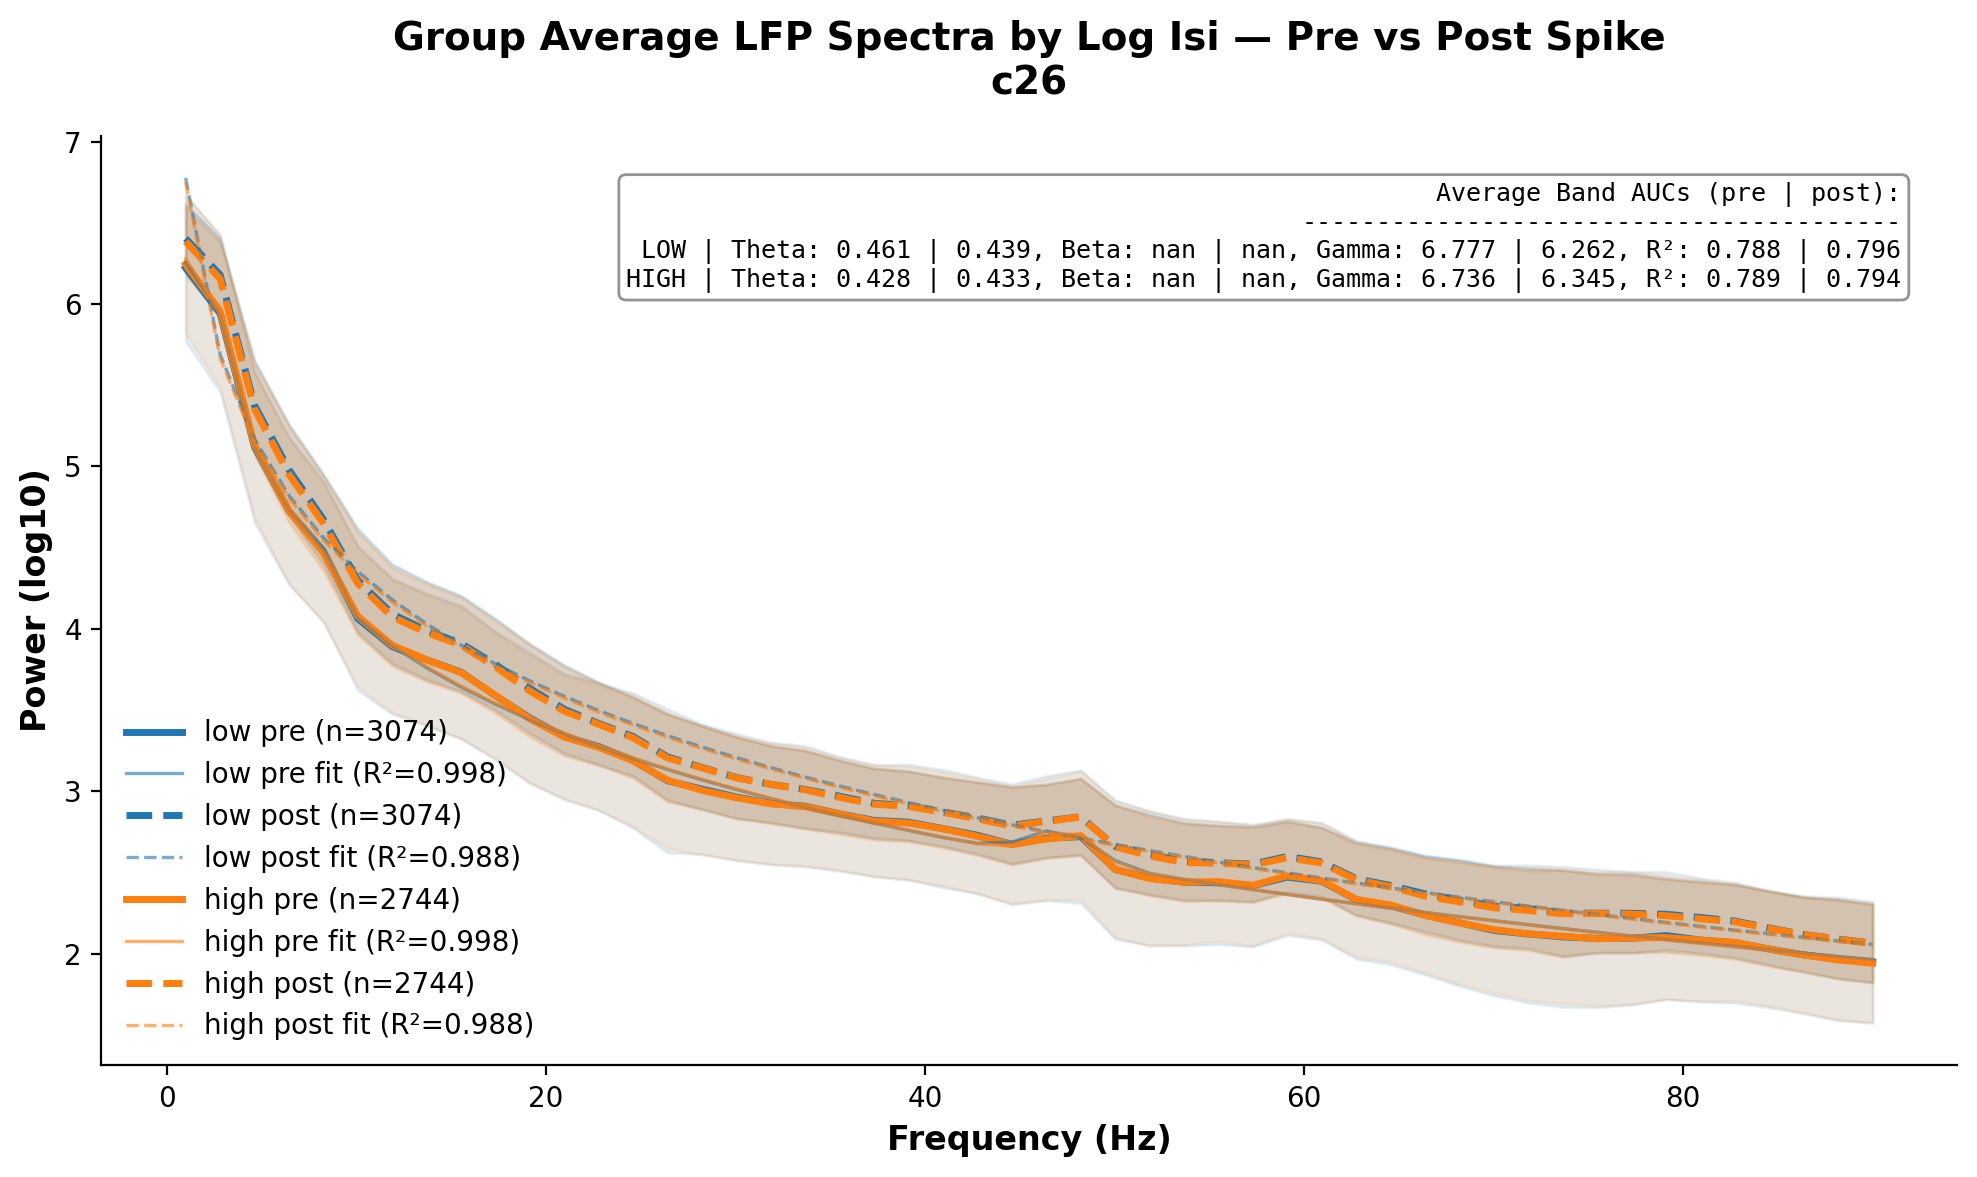

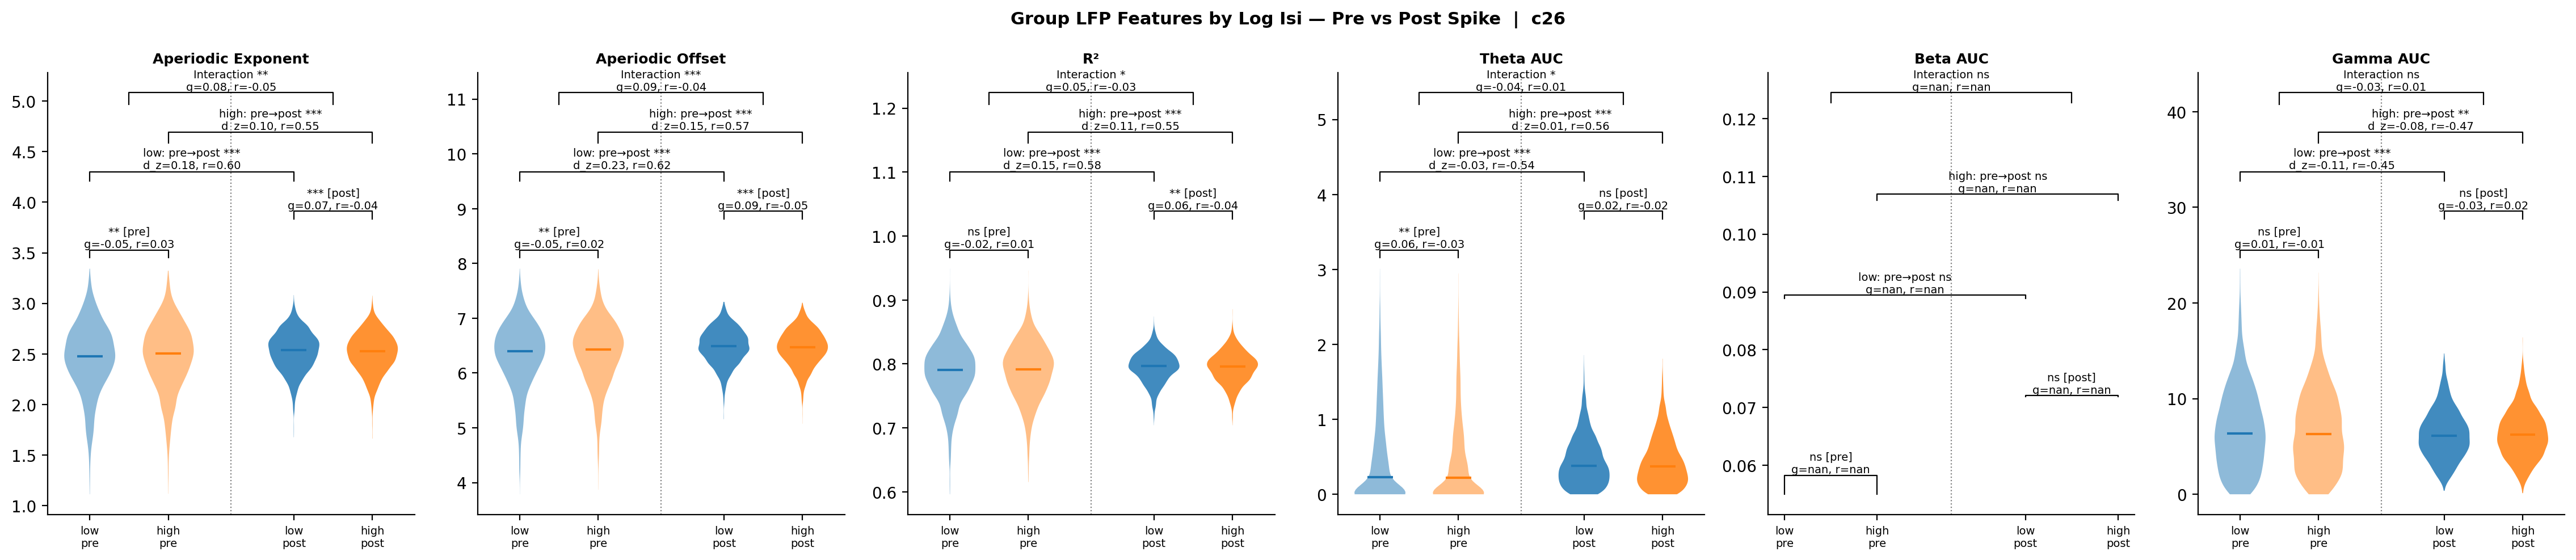

  Saved: c26_prepost.pkl


In [9]:
# Pre / post spike specparam comparison
prepost_save = os.path.join(SPE1_PICKLE_ROOT, 'prepost_specparam_pickles', f'c{cell_num}_prepost.pkl')

prepost_results = compute_pre_post_specparam_comparison(
    specparam_by_spike = specparam_by_spike,
    df_features_clust  = df_features_clust,
    pre_window         = (-0.5, -0.05),
    post_window        = (0.05, 1.0),
    n_bootstrap        = 1000,
    p_thresh           = 0.05,
    plot               = True,
    cell_id            = f'c{cell_num}',
    save_path          = prepost_save,
    force              = FORCE_PREPOST,
)